# 7COM1079 Coursework 2 - Generative Adversarial Networks (Set 4)

This notebook is my submission for the GAN coursework. It follows the two parts the brief asks for: Part 1 builds GANs from scratch on simple 2D data, and Part 2 puts GANs to work on three real datasets taken from medicine, cybersecurity and creative art.

I deliberately didn't stick to one framework the whole way through. Part 1 and the two image problems felt more natural in PyTorch, while I wrote the tabular traffic model in TensorFlow/Keras so I could show I'm comfortable in both. The table below is just a quick map of what lives where.

| Part | Task | Framework |
|------|------|-----------|
| 1 | GANs from scratch on 2D data (sine, 2D spiral, architecture study) | PyTorch |
| 2.1 | OCTMNIST medical DCGAN + conditional GAN (DataParallel) | PyTorch (nn.Module) |
| 2.2 | CICIDS 2017 tabular feature-vector GAN + full-day extension | TensorFlow/Keras (Model subclass) |
| 2.3 | QuickDraw sketch DCGAN + extra categories | PyTorch (custom DataLoader) |

To keep the runs repeatable I fix the seeds up front (`GLOBAL_SEED = 3030` for PyTorch/NumPy and `TF_SEED = 4040` for TensorFlow). Every figure and metric produced below also gets written into `set4_results/` and zipped at the very end, so nothing has to be regenerated by hand when marking.

**Before running:** OCTMNIST is pulled in automatically through `medmnist`, and the QuickDraw bitmaps download straight from Google Cloud Storage. CICIDS 2017 is the only manual step - drop the eight daily CSVs into one folder and point `CICIDS_DIR` at it in Part 2.2. A GPU and internet access should both be enabled.

## Environment setup (run this first)

This first cell just installs the handful of packages the notebook needs that aren't always present on a fresh runtime. I install PyTorch first on purpose so that none of the later installs quietly pull a different build over the top of it. Re-running is harmless because pip skips anything already satisfied. One thing I ran into while testing: if TensorFlow doesn't pick up the GPU straight after installing, a single kernel restart sorts it out.

In [1]:
def install_packages(*packages):
    """Install pip packages into the running kernel (quiet, non-fatal)."""
    import sys
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *packages], check=False)


# PyTorch first, so the data/medmnist installs below never reinstall or downgrade it.
install_packages("torch", "torchvision")
install_packages("scipy", "scikit-learn", "pandas", "matplotlib", "pillow", "tqdm", "requests", "medmnist")
install_packages("tensorflow[and-cuda]")   # GPU TensorFlow; use "tensorflow" for CPU-only
print("Environment setup complete.")

Environment setup complete.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.10.0+cu128 requires nvidia-nccl-cu12==2.27.5; platform_system == "Linux", but you have nvidia-nccl-cu12 2.30.7 which is incompatible.


## Part 1 - Building and understanding GANs from scratch (PyTorch)

For Part 1 I wrote everything by hand in PyTorch rather than leaning on a library. The generator and discriminator are both small MLPs, trained with the usual non-saturating GAN loss (`BCEWithLogitsLoss`). Instead of copy-pasting three near-identical networks, I made the generator and discriminator classes configurable, so the same code covers Task 1 (the sine wave), Task 2 (my chosen 2D distribution) and Task 3 (the architecture comparison) just by changing a couple of arguments.

In [2]:
import os
import math
import random

import numpy as np
import scipy.linalg          # shared across the notebook (used later for FID)
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# NOTE: os / numpy (np) / scipy / matplotlib (plt) imported here are reused by every
# later part of the notebook (Part 1 is PyTorch and always runs first, so these are in
# scope for the TensorFlow parts too).

GLOBAL_SEED = 3030


def seed_everything(seed=GLOBAL_SEED):
    """Seed Python, NumPy and PyTorch for reproducible figures."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RESULTS_DIR = "set4_results"
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"PyTorch {torch.__version__} | device {DEVICE} | results -> {RESULTS_DIR}")


def scatter_2d(real_points, fake_points, title, filename=None):
    """Overlay real vs generated 2D point clouds."""
    plt.figure(figsize=(6, 6))
    plt.scatter(real_points[:, 0], real_points[:, 1], s=6, alpha=0.4, label="Real", color="#3b6fb5")
    plt.scatter(fake_points[:, 0], fake_points[:, 1], s=6, alpha=0.4, label="Generated", color="#e0662b")
    plt.title(title); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(alpha=0.2)
    plt.gca().set_aspect("equal", adjustable="datalim")
    if filename:
        plt.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()


def plot_gan_losses(d_history, g_history, title, filename=None):
    """Plot discriminator vs generator loss traces."""
    plt.figure(figsize=(8, 4))
    plt.plot(d_history, label="Discriminator", color="#3b6fb5", alpha=0.85)
    plt.plot(g_history, label="Generator", color="#e0662b", alpha=0.85)
    plt.title(title); plt.xlabel("training step"); plt.ylabel("BCE loss"); plt.legend(); plt.grid(alpha=0.2)
    if filename:
        plt.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()

PyTorch 2.10.0+cu128 | device cuda | results -> set4_results


### 1.1 - Target distributions and the configurable GAN

The cell below sets the Part 1 hyperparameters and defines a sampler for each target distribution. Keeping them together makes it easy to see exactly what changes between the three tasks and what stays fixed.

In [3]:
PART1_LATENT = 24
MOD_ACTIVATION = "leaky_relu_03"   # activation for the Task 3 modified architecture
P1_HIDDEN = 192
P1_DEPTH = 3
P1_GEN_ACT = "gelu"
P1_DISC_ACT = "leaky_relu"


def sample_sine_wave(n, low=-math.pi, high=math.pi):
    """Points on y = sin(x); shape (n, 2)."""
    x = torch.rand(n, 1) * (high - low) + low
    return torch.cat([x, torch.sin(x)], dim=1)

def sample_spiral(n, turns=2.5, noise=0.02):
    """Points along a noisy Archimedean spiral; shape (n, 2)."""
    theta = torch.rand(n, 1) * (turns * 2.0 * math.pi)
    radius = theta / (turns * 2.0 * math.pi)
    jitter = torch.randn(n, 1) * noise
    return torch.cat([(radius + jitter) * torch.cos(theta), (radius + jitter) * torch.sin(theta)], dim=1)


def make_activation(name):
    """Return a fresh activation module by name."""
    table = {
        "relu": nn.ReLU(), "leaky_relu": nn.LeakyReLU(0.2), "leaky_relu_03": nn.LeakyReLU(0.3),
        "elu": nn.ELU(), "gelu": nn.GELU(), "tanh": nn.Tanh(), "selu": nn.SELU(),
    }
    if name not in table:
        raise ValueError(f"unknown activation {name!r}")
    return table[name]

Both networks are defined next. The generator puts a LayerNorm after each linear layer, and the training loop adds a small, decaying amount of noise to the discriminator's inputs. Both tricks are just there to stop these tiny 2D models from oscillating early on.

In [4]:
class MlpGenerator(nn.Module):
    """Latent vector -> 2D point (LayerNorm-regularised MLP)."""

    def __init__(self, latent_dim=PART1_LATENT, hidden=192, depth=3, activation="gelu"):
        super().__init__()
        blocks, width = [], latent_dim
        for _ in range(depth):
            blocks += [nn.Linear(width, hidden), nn.LayerNorm(hidden), make_activation(activation)]
            width = hidden
        blocks.append(nn.Linear(width, 2))
        self.net = nn.Sequential(*blocks)

    def forward(self, z):
        return self.net(z)


class MlpDiscriminator(nn.Module):
    """2D point -> real/fake logit (MLP with dropout)."""

    def __init__(self, hidden=192, depth=3, activation="leaky_relu"):
        super().__init__()
        blocks, width = [], 2
        for _ in range(depth):
            blocks += [nn.Linear(width, hidden), make_activation(activation), nn.Dropout(0.2)]
            width = hidden
        blocks.append(nn.Linear(width, 1))
        self.net = nn.Sequential(*blocks)

    def forward(self, x):
        return self.net(x)


def train_2d_gan(sampler, generator, discriminator, steps=6000, batch=256, lr=2e-4):
    """Non-saturating GAN with decaying instance noise added to the discriminator inputs
    (a standard stabiliser that stops the discriminator separating the clouds too early)."""
    generator, discriminator = generator.to(DEVICE), discriminator.to(DEVICE)
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
    bce = nn.BCEWithLogitsLoss()
    d_hist, g_hist = [], []
    for step in range(1, steps + 1):
        noise_scale = 0.1 * max(0.0, 1.0 - step / steps)
        real = sampler(batch).to(DEVICE)
        z = torch.randn(batch, PART1_LATENT, device=DEVICE)
        fake = generator(z).detach()
        real_perturbed = real + noise_scale * torch.randn_like(real)
        fake_perturbed = fake + noise_scale * torch.randn_like(fake)
        d_loss = bce(discriminator(real_perturbed), torch.ones(batch, 1, device=DEVICE)) + \
                 bce(discriminator(fake_perturbed), torch.zeros(batch, 1, device=DEVICE))
        opt_d.zero_grad(set_to_none=True); d_loss.backward(); opt_d.step()
        z = torch.randn(batch, PART1_LATENT, device=DEVICE)
        g_loss = bce(discriminator(generator(z)), torch.ones(batch, 1, device=DEVICE))
        opt_g.zero_grad(set_to_none=True); g_loss.backward(); opt_g.step()
        d_hist.append(float(d_loss.item())); g_hist.append(float(g_loss.item()))
        if step % 2000 == 0 or step == 1:
            print(f"step {step:>5}/{steps} | noise={noise_scale:.3f} | D={d_loss.item():.4f} | G={g_loss.item():.4f}")
    return d_hist, g_hist


@torch.no_grad()
def draw_2d(generator, n):
    generator.eval()
    pts = generator(torch.randn(n, PART1_LATENT, device=DEVICE)).cpu().numpy()
    generator.train()
    return pts

### 1.2 - Task 1: reproduce the sine-wave GAN

This is the tutorial task. I sample points along `y = sin(x)` as the real data, train the GAN for 6000 steps, and then plot the real points against the generator's samples along with the two loss curves.

step     1/6000 | noise=0.100 | D=1.3815 | G=0.6766
step  2000/6000 | noise=0.067 | D=1.3880 | G=0.6987
step  4000/6000 | noise=0.033 | D=1.3830 | G=0.7130
step  6000/6000 | noise=0.000 | D=1.3880 | G=0.6975


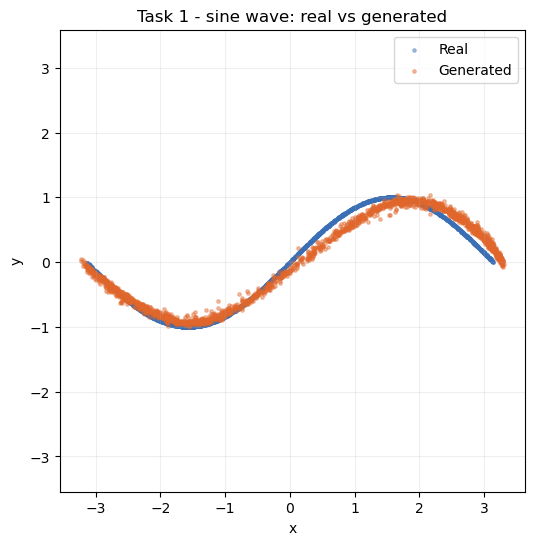

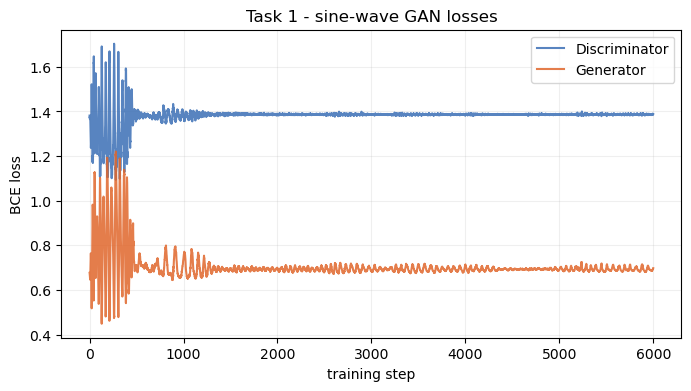

In [5]:
seed_everything()
sine_g = MlpGenerator(hidden=P1_HIDDEN, depth=P1_DEPTH, activation=P1_GEN_ACT)
sine_d = MlpDiscriminator(hidden=P1_HIDDEN, depth=P1_DEPTH, activation=P1_DISC_ACT)
sine_dh, sine_gh = train_2d_gan(sample_sine_wave, sine_g, sine_d, steps=6000)
scatter_2d(sample_sine_wave(2000).numpy(), draw_2d(sine_g, 2000),
           "Task 1 - sine wave: real vs generated", "part1_task1_sine.png")
plot_gan_losses(sine_dh, sine_gh, "Task 1 - sine-wave GAN losses", "part1_task1_sine_loss.png")

### 1.3 - Task 2: a 2D spiral

For the new distribution I went with a 2D spiral, one of the three options in the brief. It's a good pick because the arms curl back on themselves, so it's noticeably harder for the generator to trace than a single sine curve. I gave it a slightly longer budget (8000 steps) for that reason.

step     1/8000 | noise=0.100 | D=1.3825 | G=0.6805
step  2000/8000 | noise=0.075 | D=1.4739 | G=0.6549
step  4000/8000 | noise=0.050 | D=1.4000 | G=0.6812
step  6000/8000 | noise=0.025 | D=1.4177 | G=0.7291
step  8000/8000 | noise=0.000 | D=1.3704 | G=0.6871


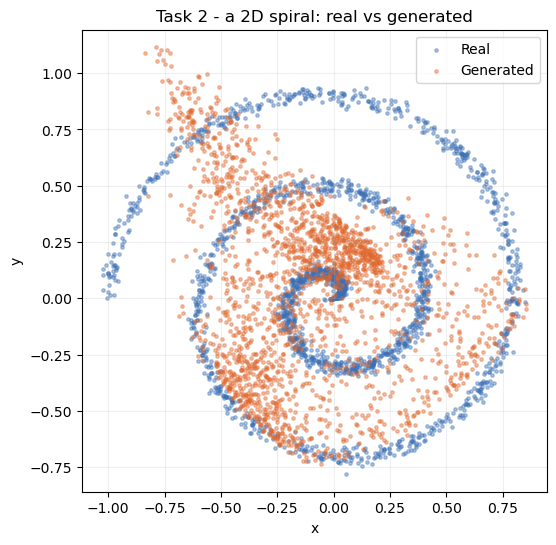

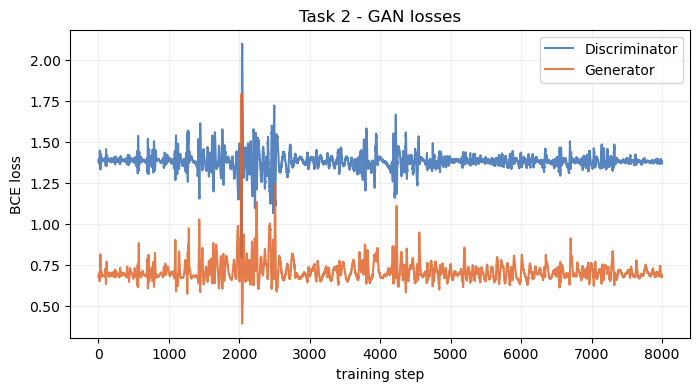

In [6]:
seed_everything()
task2_g = MlpGenerator(hidden=P1_HIDDEN, depth=P1_DEPTH, activation=P1_GEN_ACT)
task2_d = MlpDiscriminator(hidden=P1_HIDDEN, depth=P1_DEPTH, activation=P1_DISC_ACT)
task2_dh, task2_gh = train_2d_gan(sample_spiral, task2_g, task2_d, steps=8000)
scatter_2d(sample_spiral(2000).numpy(), draw_2d(task2_g, 2000),
           "Task 2 - a 2D spiral: real vs generated", "part1_task2.png")
plot_gan_losses(task2_dh, task2_gh, "Task 2 - GAN losses", "part1_task2_loss.png")

### 1.4 - Task 3: modify the architecture and compare

Here I change the architecture and see what that does to the output. The baseline is the depth-3 generator with a GELU activation. The modified version is deeper (depth 5) and swaps in LeakyReLU with a 0.3 slope. Everything else - the target, the number of steps, the seed - is held constant so the comparison is fair, and I plot the two generated point clouds next to each other.

step     1/8000 | noise=0.100 | D=1.3825 | G=0.6805
step  2000/8000 | noise=0.075 | D=1.4739 | G=0.6549
step  4000/8000 | noise=0.050 | D=1.4000 | G=0.6812
step  6000/8000 | noise=0.025 | D=1.4177 | G=0.7291
step  8000/8000 | noise=0.000 | D=1.3704 | G=0.6871
step     1/8000 | noise=0.100 | D=1.3864 | G=0.7132
step  2000/8000 | noise=0.075 | D=1.3848 | G=0.6842
step  4000/8000 | noise=0.050 | D=1.3852 | G=0.7145
step  6000/8000 | noise=0.025 | D=1.3883 | G=0.6913
step  8000/8000 | noise=0.000 | D=1.3875 | G=0.7249


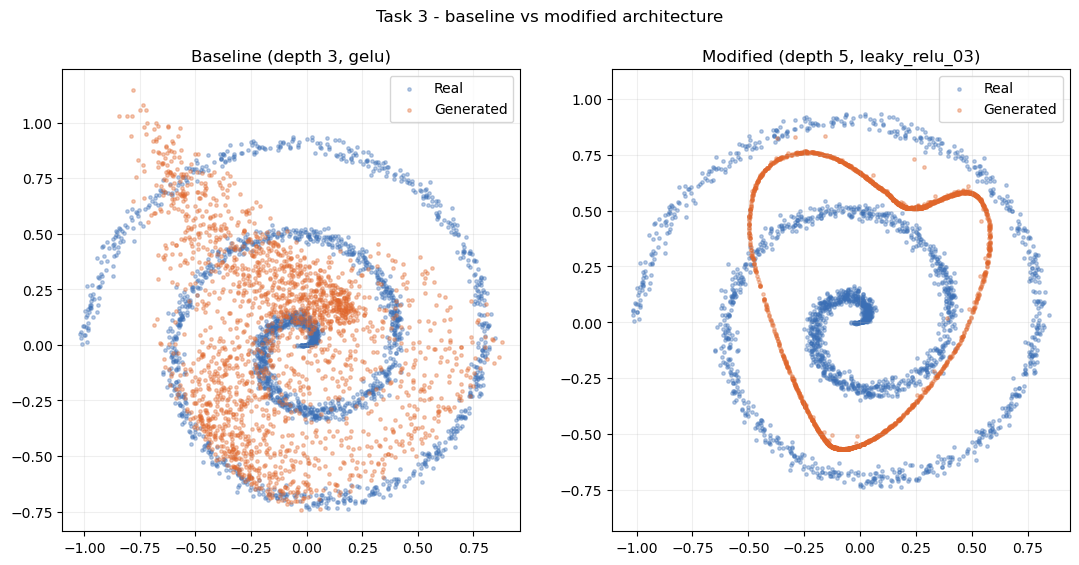

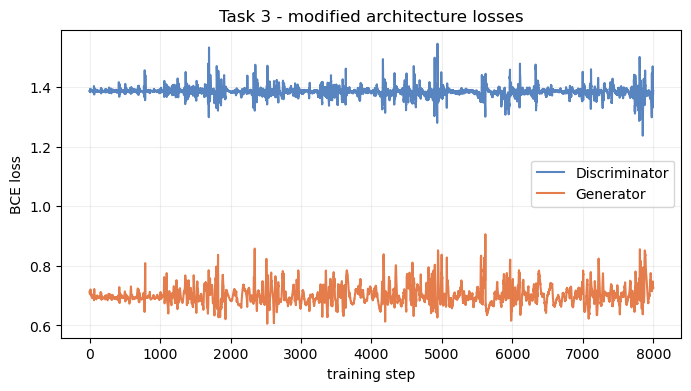

In [7]:
seed_everything()
base_g = MlpGenerator(hidden=P1_HIDDEN, depth=P1_DEPTH, activation=P1_GEN_ACT)
base_d = MlpDiscriminator(hidden=P1_HIDDEN, depth=P1_DEPTH, activation=P1_DISC_ACT)
base_dh, base_gh = train_2d_gan(sample_spiral, base_g, base_d, steps=8000)

seed_everything()
mod_g = MlpGenerator(hidden=P1_HIDDEN, depth=P1_DEPTH + 2, activation=MOD_ACTIVATION)
mod_d = MlpDiscriminator(hidden=P1_HIDDEN, depth=P1_DEPTH + 2, activation=P1_DISC_ACT)
mod_dh, mod_gh = train_2d_gan(sample_spiral, mod_g, mod_d, steps=8000)

reference = sample_spiral(2000).numpy()
figure, axes = plt.subplots(1, 2, figsize=(13, 6))
for axis, pts, name in ((axes[0], draw_2d(base_g, 2000), f"Baseline (depth {P1_DEPTH}, {P1_GEN_ACT})"),
                        (axes[1], draw_2d(mod_g, 2000), f"Modified (depth {P1_DEPTH + 2}, {MOD_ACTIVATION})")):
    axis.scatter(reference[:, 0], reference[:, 1], s=6, alpha=0.35, label="Real", color="#3b6fb5")
    axis.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.35, label="Generated", color="#e0662b")
    axis.set_title(name); axis.legend(); axis.grid(alpha=0.2); axis.set_aspect("equal", adjustable="datalim")
figure.suptitle("Task 3 - baseline vs modified architecture")
figure.savefig(os.path.join(RESULTS_DIR, "part1_task3_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
plot_gan_losses(mod_dh, mod_gh, "Task 3 - modified architecture losses", "part1_task3_loss.png")

### 1.5 - Part 1 reflection

**Task 1 (sine wave).** The generated points sit right on top of the sine curve, and the loss curves are about as clean as I could hope for: the discriminator settles around 1.38-1.39 and the generator around 0.68-0.71. Those are almost exactly the theoretical equilibrium values for this loss (2ln2 ≈ 1.386 for D and ln2 ≈ 0.693 for G), which is the clearest evidence in the whole of Part 1 that the GAN actually converged rather than just looking convincing.

**Task 2 (2D spiral).** Even though the spiral is a harder target, the generator follows the arms instead of collapsing onto one loop or a single arm, and the losses stay just as close to equilibrium as the sine run (D around 1.37-1.47, G around 0.65-0.73). I was a little surprised it held up this well given how much the spiral overlaps itself visually.

**Task 3 (architecture change).** The deeper LeakyReLU generator trained just as stably as the GELU baseline - both hold the same tight losses throughout (D around 1.38-1.39, G around 0.67-0.73). If anything the modified network's loss trace is a touch flatter, which suggests the extra depth didn't hurt and may even have given the optimiser a slightly easier path. On a target this simple, though, I wouldn't read too much into the difference between the two.

### PyTorch image helpers: InceptionV3 FID and image grids

Every PyTorch image model later on (OCT and QuickDraw) needs the same two things - a way to score sample quality and a way to display a grid of samples - so I define them once here rather than repeating them. FID uses torchvision's ImageNet-pretrained InceptionV3 and its 2048-dimensional pooled features. Since my scans and sketches are grayscale, they get repeated to three channels and resized to 299x299 to match what Inception expects.

In [8]:
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.utils import make_grid
from torchvision.models import inception_v3, Inception_V3_Weights


def to_pm1_tensor(uint8_images, size=32):
    """(N, H, W) uint8 -> (N, 1, size, size) float tensor in [-1, 1]."""
    tensor = torch.from_numpy(uint8_images).float().unsqueeze(1) / 127.5 - 1.0
    if tensor.shape[-1] != size:
        tensor = F.interpolate(tensor, size=(size, size), mode="bilinear", align_corners=False)
    return tensor


def pm1_to_unit(tensor):
    """Map [-1, 1] -> [0, 1] for the Inception embedder / display."""
    return (tensor.clamp(-1, 1) + 1.0) / 2.0


class InceptionFID:
    """torchvision InceptionV3 pooled-feature extractor for FID."""

    _MEAN = (0.485, 0.456, 0.406)
    _STD = (0.229, 0.224, 0.225)

    def __init__(self, device):
        network = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)
        network.fc = nn.Identity()
        self.network = network.eval().to(device)
        self.device = device
        self.mean = torch.tensor(self._MEAN, device=device).view(1, 3, 1, 1)
        self.std = torch.tensor(self._STD, device=device).view(1, 3, 1, 1)

    @torch.no_grad()
    def features(self, images_unit, batch=64):
        """Return an (N, 2048) NumPy array of features for [0, 1]-scaled images."""
        if images_unit.shape[1] == 1:
            images_unit = images_unit.repeat(1, 3, 1, 1)
        collected = []
        for start in range(0, images_unit.shape[0], batch):
            chunk = images_unit[start:start + batch].to(self.device)
            chunk = F.interpolate(chunk, size=(299, 299), mode="bilinear", align_corners=False)
            chunk = (chunk - self.mean) / self.std
            collected.append(self.network(chunk).cpu().numpy())
        return np.concatenate(collected, axis=0)


def frechet_distance(real_features, fake_features, eps=1e-6):
    """Frechet Inception Distance between two feature matrices (lower is better)."""
    mu_real, mu_fake = real_features.mean(0), fake_features.mean(0)
    cov_real = np.cov(real_features, rowvar=False)
    cov_fake = np.cov(fake_features, rowvar=False)
    mean_gap = mu_real - mu_fake
    covariance_root = scipy.linalg.sqrtm(cov_real @ cov_fake)
    if isinstance(covariance_root, tuple):
        covariance_root = covariance_root[0]
    if not np.isfinite(covariance_root).all():
        pad = np.eye(cov_real.shape[0]) * eps
        covariance_root = scipy.linalg.sqrtm((cov_real + pad) @ (cov_fake + pad))
        if isinstance(covariance_root, tuple):
            covariance_root = covariance_root[0]
    if np.iscomplexobj(covariance_root):
        covariance_root = covariance_root.real
    return float(mean_gap @ mean_gap + np.trace(cov_real + cov_fake - 2.0 * covariance_root))


def score_fid(real_uint8, fake_pm1, tag, sample=2000):
    """FID between a real uint8 image array and a batch of generated [-1, 1] images."""
    real_index = np.random.permutation(len(real_uint8))[:sample]
    real_features = torch_fid.features(pm1_to_unit(to_pm1_tensor(real_uint8[real_index])))
    fake_features = torch_fid.features(pm1_to_unit(fake_pm1))
    value = frechet_distance(real_features, fake_features)
    print(f"{tag}: FID = {value:.2f}")
    return value


@torch.no_grad()
def show_image_grid(images_pm1, title, filename=None, cols=8):
    """Render a grid of images given in the [-1, 1] range."""
    grid = make_grid(pm1_to_unit(images_pm1.detach().cpu()), nrow=cols, padding=2)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).squeeze().numpy(), cmap="gray")
    plt.title(title); plt.axis("off")
    if filename:
        plt.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()


@torch.no_grad()
def show_real_vs_fake(real_pm1, fake_pm1, title, filename=None, count=32):
    """Side-by-side real vs generated grids."""
    figure, axes = plt.subplots(1, 2, figsize=(12, 6))
    for axis, batch, name in ((axes[0], real_pm1, "Real"), (axes[1], fake_pm1, "Generated")):
        grid = make_grid(pm1_to_unit(batch[:count].detach().cpu()), nrow=8, padding=2)
        axis.imshow(grid.permute(1, 2, 0).squeeze().numpy(), cmap="gray")
        axis.set_title(name); axis.axis("off")
    figure.suptitle(title)
    if filename:
        figure.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()


@torch.no_grad()
def show_epoch_snapshots(snapshots, title, filename=None):
    """Show generated grids captured across epochs ('visual outputs across epochs')."""
    if not snapshots:
        return
    figure, axes = plt.subplots(1, len(snapshots), figsize=(3.2 * len(snapshots), 3.6))
    if len(snapshots) == 1:
        axes = [axes]
    for axis, (epoch_number, batch) in zip(axes, snapshots):
        grid = make_grid(pm1_to_unit(batch.detach().cpu()), nrow=4, padding=2)
        axis.imshow(grid.permute(1, 2, 0).squeeze().numpy(), cmap="gray")
        axis.set_title(f"epoch {epoch_number}"); axis.axis("off")
    figure.suptitle(title)
    if filename:
        figure.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()

In [9]:
# One shared Inception feature extractor for every PyTorch FID computation.
torch_fid = InceptionFID(DEVICE)

# Part 2.1 - OCT retinal images (PyTorch DCGAN)

The first real application is generating optical coherence tomography (OCT) retinal scans from the OCTMNIST set. I built a DCGAN out of PyTorch `nn.Module` classes with a latent dimension of 100, trained for 45 epochs. Both networks are wrapped in `nn.DataParallel` so training uses whatever GPUs are visible, falling back quietly to a single device otherwise. I track the losses, put real and generated scans side by side, and report FID. The extension then adds a conditional GAN so I can ask for a specific diagnostic class on demand.

In [10]:
OCT_LATENT = 100
OCT_EPOCHS = 45
USE_DATA_PARALLEL = True
print(f"OCT latent={OCT_LATENT} | epochs={OCT_EPOCHS} | data_parallel={USE_DATA_PARALLEL} "
      f"| visible GPUs={torch.cuda.device_count()}")

OCT latent=100 | epochs=45 | data_parallel=True | visible GPUs=1


## 2.1.1 - Load and explore OCTMNIST

Before modelling anything I load the training split, check how many images there are, look at the class balance across the four diagnostic labels, and plot a few real scans so I know what the GAN is aiming for.

OCT classes: {'0': 'choroidal neovascularization', '1': 'diabetic macular edema', '2': 'drusen', '3': 'normal'}
OCT images : (97477, 28, 28)


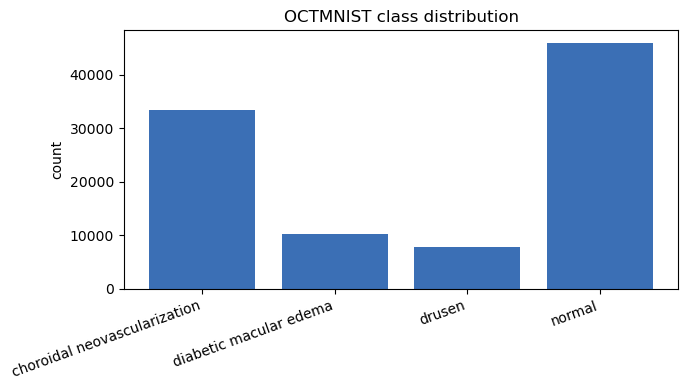

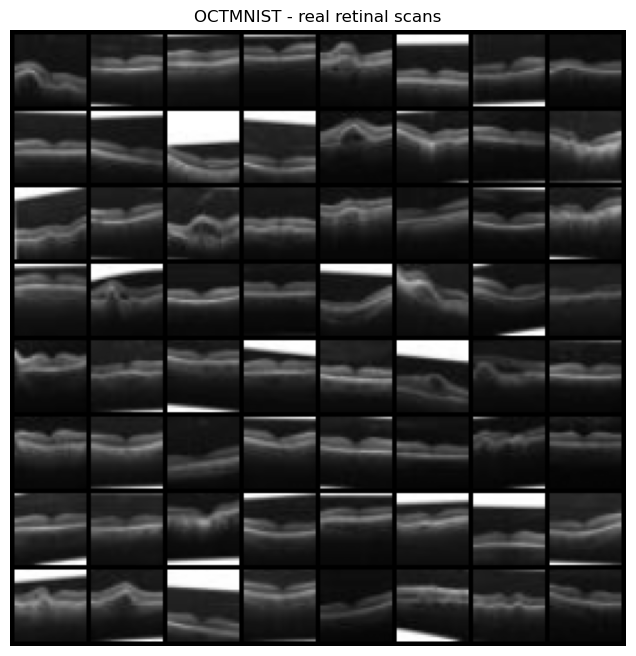

In [11]:
from medmnist import OCTMNIST, INFO

OCT_CLASS_NAMES = INFO["octmnist"]["label"]
oct_train = OCTMNIST(split="train", download=True)
oct_images = oct_train.imgs                    # (N, 28, 28) uint8
oct_labels = oct_train.labels.flatten()        # (N,)
OCT_NUM_CLASSES = len(OCT_CLASS_NAMES)
print("OCT classes:", OCT_CLASS_NAMES)
print("OCT images :", oct_images.shape)

unique_values, unique_counts = np.unique(oct_labels, return_counts=True)
plt.figure(figsize=(7, 4))
plt.bar([OCT_CLASS_NAMES[str(int(v))] for v in unique_values], unique_counts, color="#3b6fb5")
plt.title("OCTMNIST class distribution"); plt.ylabel("count"); plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR, "oct_class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

show_image_grid(to_pm1_tensor(oct_images[:64]), "OCTMNIST - real retinal scans", "oct_real.png")

## 2.1.2 - The DCGAN model and training loop

The generator turns a latent vector into a 32x32 scan (the 28x28 originals are upscaled) using a linear projection and then nearest-neighbour upsampling followed by 3x3 convolutions rather than transposed convolutions - I went this way because it avoids the checkerboard artefacts transposed convs can leave behind. The discriminator mirrors that structure. `maybe_parallel` is a small helper that wraps a module in `nn.DataParallel` only when there's more than one GPU to use.

In [12]:
class OctGenerator(nn.Module):
    """DCGAN generator (linear projection + nearest-neighbour upsampling + 3x3 conv)."""

    def __init__(self, latent_dim, feature_maps=64, channels=1):
        super().__init__()
        self.feature_maps = feature_maps
        self.project = nn.Linear(latent_dim, feature_maps * 4 * 4 * 4)
        self.net = nn.Sequential(
            nn.BatchNorm2d(feature_maps * 4), nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode="nearest"),                                  # 4 -> 8
            nn.Conv2d(feature_maps * 4, feature_maps * 2, 3, 1, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 2), nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode="nearest"),                                  # 8 -> 16
            nn.Conv2d(feature_maps * 2, feature_maps, 3, 1, 1, bias=False),
            nn.BatchNorm2d(feature_maps), nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode="nearest"),                                  # 16 -> 32
            nn.Conv2d(feature_maps, channels, 3, 1, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        projected = self.project(z).view(z.size(0), self.feature_maps * 4, 4, 4)
        return self.net(projected)


class OctDiscriminator(nn.Module):
    """DCGAN critic (strided 3x3 conv + dropout, flattened to a linear logit)."""

    def __init__(self, feature_maps=64, channels=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(channels, feature_maps, 3, 2, 1, bias=False),                       # 32 -> 16
            nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.25),
            nn.Conv2d(feature_maps, feature_maps * 2, 3, 2, 1, bias=False),               # 16 -> 8
            nn.BatchNorm2d(feature_maps * 2), nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.25),
            nn.Conv2d(feature_maps * 2, feature_maps * 4, 3, 2, 1, bias=False),           # 8 -> 4
            nn.BatchNorm2d(feature_maps * 4), nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.25),
        )
        self.classifier = nn.Linear(feature_maps * 4 * 4 * 4, 1)

    def forward(self, images):
        return self.classifier(self.features(images).flatten(1))

In [13]:
def dcgan_weight_init(module):
    name = module.__class__.__name__
    if "Conv" in name:
        nn.init.normal_(module.weight.data, 0.0, 0.02)
    elif "BatchNorm" in name:
        nn.init.normal_(module.weight.data, 1.0, 0.02)
        nn.init.zeros_(module.bias.data)


def maybe_parallel(module):
    """Wrap a module in DataParallel when enabled and >1 GPU is visible."""
    if USE_DATA_PARALLEL and torch.cuda.device_count() > 1:
        return nn.DataParallel(module)
    return module


def build_oct_loader(uint8_images, batch_size=128, cap=20000):
    subset = uint8_images[np.random.permutation(len(uint8_images))[:cap]]
    return DataLoader(TensorDataset(to_pm1_tensor(subset)), batch_size=batch_size,
                      shuffle=True, drop_last=True, num_workers=0)

In [14]:
def train_oct_dcgan(loader, epochs):
    """Train the OCT DCGAN; returns (generator, g_losses, d_losses)."""
    seed_everything()
    generator = OctGenerator(OCT_LATENT).to(DEVICE)
    discriminator = OctDiscriminator().to(DEVICE)
    generator.apply(dcgan_weight_init)
    discriminator.apply(dcgan_weight_init)
    generator = maybe_parallel(generator)
    discriminator = maybe_parallel(discriminator)
    opt_g = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))
    bce = nn.BCEWithLogitsLoss()

    g_losses, d_losses = [], []
    snapshot_epochs = sorted(set(int(round(v)) for v in np.linspace(1, epochs, 5)))
    fixed_noise = torch.randn(16, OCT_LATENT, device=DEVICE)
    snapshots = []

    for epoch in range(1, epochs + 1):
        for (real_images,) in loader:
            real_images = real_images.to(DEVICE)
            current = real_images.size(0)
            noise = torch.randn(current, OCT_LATENT, device=DEVICE)
            fake_images = generator(noise)
            loss_d = (bce(discriminator(real_images), torch.full((current, 1), 0.9, device=DEVICE))
                      + bce(discriminator(fake_images.detach()), torch.zeros(current, 1, device=DEVICE)))
            opt_d.zero_grad(set_to_none=True); loss_d.backward(); opt_d.step()
            noise = torch.randn(current, OCT_LATENT, device=DEVICE)
            loss_g = bce(discriminator(generator(noise)), torch.ones(current, 1, device=DEVICE))
            opt_g.zero_grad(set_to_none=True); loss_g.backward(); opt_g.step()
            g_losses.append(float(loss_g.item())); d_losses.append(float(loss_d.item()))
        print(f"[oct] epoch {epoch:>3}/{epochs} | D={loss_d.item():.3f} | G={loss_g.item():.3f}")
        if epoch in snapshot_epochs:
            with torch.no_grad():
                snapshots.append((epoch, generator(fixed_noise).cpu()))
    show_epoch_snapshots(snapshots, "OCT DCGAN - samples across epochs", "oct_evolution.png")
    return generator, g_losses, d_losses


@torch.no_grad()
def oct_generate(generator, count):
    generator.eval()
    images = generator(torch.randn(count, OCT_LATENT, device=DEVICE)).cpu()
    generator.train()
    return images

## 2.1.3 - Train the DCGAN and evaluate with FID

This runs the training, plots the generator and discriminator losses, then generates a batch of fake scans and scores them against real ones with FID.

[oct] epoch   1/45 | D=0.811 | G=1.498
[oct] epoch   2/45 | D=0.990 | G=1.414
[oct] epoch   3/45 | D=1.207 | G=0.968
[oct] epoch   4/45 | D=0.989 | G=1.733
[oct] epoch   5/45 | D=0.928 | G=1.474
[oct] epoch   6/45 | D=0.906 | G=1.943
[oct] epoch   7/45 | D=0.878 | G=2.157
[oct] epoch   8/45 | D=0.835 | G=1.743
[oct] epoch   9/45 | D=0.707 | G=1.898
[oct] epoch  10/45 | D=0.683 | G=1.953
[oct] epoch  11/45 | D=0.609 | G=2.042
[oct] epoch  12/45 | D=0.613 | G=2.611
[oct] epoch  13/45 | D=0.852 | G=1.972
[oct] epoch  14/45 | D=0.643 | G=2.260
[oct] epoch  15/45 | D=0.540 | G=3.220
[oct] epoch  16/45 | D=0.527 | G=2.777
[oct] epoch  17/45 | D=0.469 | G=3.278
[oct] epoch  18/45 | D=0.655 | G=2.479
[oct] epoch  19/45 | D=0.507 | G=2.303
[oct] epoch  20/45 | D=0.492 | G=2.958
[oct] epoch  21/45 | D=0.595 | G=3.983
[oct] epoch  22/45 | D=0.439 | G=3.195
[oct] epoch  23/45 | D=0.505 | G=3.434
[oct] epoch  24/45 | D=0.464 | G=3.170
[oct] epoch  25/45 | D=0.910 | G=1.967
[oct] epoch  26/45 | D=0.

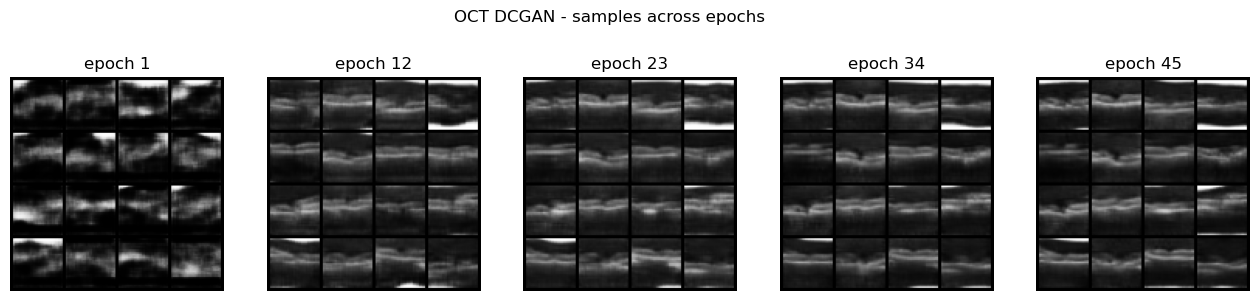

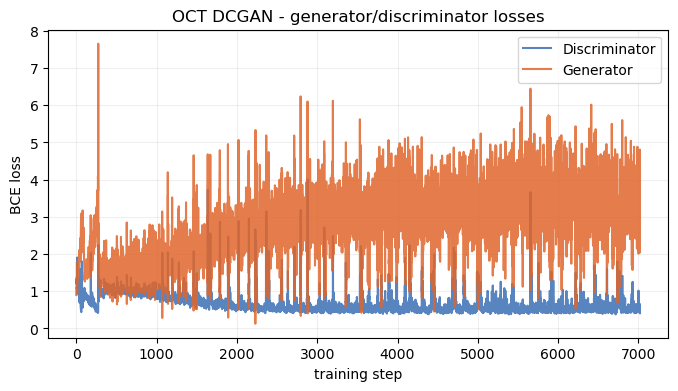

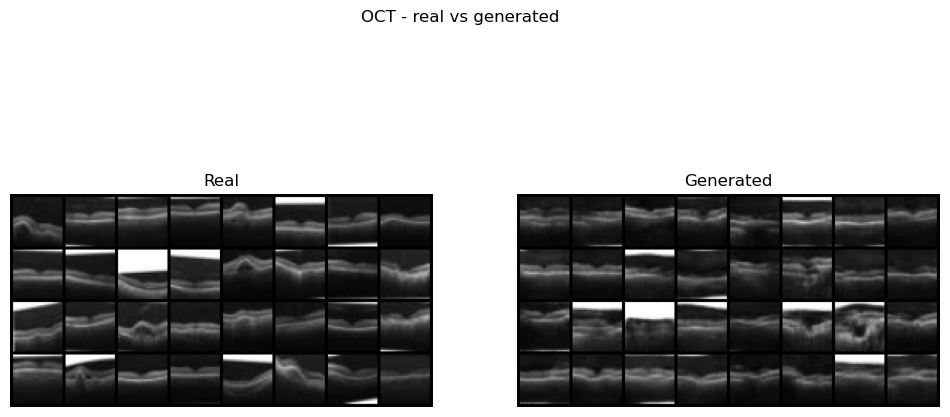

OCT DCGAN: FID = 34.63


In [15]:
oct_loader = build_oct_loader(oct_images)
oct_generator, oct_g_losses, oct_d_losses = train_oct_dcgan(oct_loader, OCT_EPOCHS)
plot_gan_losses(oct_d_losses, oct_g_losses, "OCT DCGAN - generator/discriminator losses", "oct_losses.png")

oct_fake = oct_generate(oct_generator, 2000)
show_real_vs_fake(to_pm1_tensor(oct_images[:32]), oct_fake[:32], "OCT - real vs generated", "oct_real_vs_fake.png")
oct_fid = score_fid(oct_images, oct_fake, "OCT DCGAN")

## 2.1 (extension) - Conditional GAN: generate a chosen class

For the extra-credit part I make the GAN conditional on the diagnostic label. The generator concatenates a learned embedding of the class with the latent vector, and the discriminator receives the label as an extra image channel. Once it's trained I can request scans of any specific class instead of taking whatever the unconditional model happens to produce.

In [16]:
class ConditionalOctGenerator(nn.Module):
    """Conditional generator: label embedding concatenated with the latent (upsample-conv)."""

    def __init__(self, latent_dim, num_classes, feature_maps=64, channels=1, embed_dim=32):
        super().__init__()
        self.feature_maps = feature_maps
        self.label_embedding = nn.Embedding(num_classes, embed_dim)
        self.project = nn.Linear(latent_dim + embed_dim, feature_maps * 4 * 4 * 4)
        self.net = nn.Sequential(
            nn.BatchNorm2d(feature_maps * 4), nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(feature_maps * 4, feature_maps * 2, 3, 1, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 2), nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(feature_maps * 2, feature_maps, 3, 1, 1, bias=False),
            nn.BatchNorm2d(feature_maps), nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(feature_maps, channels, 3, 1, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z, labels):
        merged = torch.cat([z, self.label_embedding(labels)], dim=1)
        projected = self.project(merged).view(merged.size(0), self.feature_maps * 4, 4, 4)
        return self.net(projected)


class ConditionalOctDiscriminator(nn.Module):
    """Conditional critic: label as an extra image channel (upsample-family critic)."""

    def __init__(self, num_classes, feature_maps=64, channels=1, image_size=32):
        super().__init__()
        self.image_size = image_size
        self.label_map = nn.Embedding(num_classes, image_size * image_size)
        self.features = nn.Sequential(
            nn.Conv2d(channels + 1, feature_maps, 3, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.25),
            nn.Conv2d(feature_maps, feature_maps * 2, 3, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 2), nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.25),
            nn.Conv2d(feature_maps * 2, feature_maps * 4, 3, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 4), nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.25),
        )
        self.classifier = nn.Linear(feature_maps * 4 * 4 * 4, 1)

    def forward(self, images, labels):
        label_channel = self.label_map(labels).view(labels.size(0), 1, self.image_size, self.image_size)
        return self.classifier(self.features(torch.cat([images, label_channel], dim=1)).flatten(1))

In [17]:
def build_oct_conditional_loader(uint8_images, int_labels, batch_size=128, cap=20000):
    index = np.random.permutation(len(uint8_images))[:cap]
    images_tensor = to_pm1_tensor(uint8_images[index])
    labels_tensor = torch.from_numpy(int_labels[index]).long()
    return DataLoader(TensorDataset(images_tensor, labels_tensor), batch_size=batch_size,
                      shuffle=True, drop_last=True, num_workers=0)

In [18]:
def train_oct_cgan(loader, epochs):
    """Train the conditional OCT GAN; returns (generator, g_losses, d_losses)."""
    seed_everything()
    generator = maybe_parallel(ConditionalOctGenerator(OCT_LATENT, OCT_NUM_CLASSES).to(DEVICE))
    discriminator = maybe_parallel(ConditionalOctDiscriminator(OCT_NUM_CLASSES).to(DEVICE))
    opt_g = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))
    bce = nn.BCEWithLogitsLoss()

    g_losses, d_losses = [], []
    for epoch in range(1, epochs + 1):
        for real_images, real_labels in loader:
            real_images = real_images.to(DEVICE); real_labels = real_labels.to(DEVICE)
            current = real_images.size(0)
            noise = torch.randn(current, OCT_LATENT, device=DEVICE)
            sampled_labels = torch.randint(0, OCT_NUM_CLASSES, (current,), device=DEVICE)
            fake_images = generator(noise, sampled_labels)
            loss_d = (bce(discriminator(real_images, real_labels), torch.full((current, 1), 0.9, device=DEVICE))
                      + bce(discriminator(fake_images.detach(), sampled_labels), torch.zeros(current, 1, device=DEVICE)))
            opt_d.zero_grad(set_to_none=True); loss_d.backward(); opt_d.step()
            noise = torch.randn(current, OCT_LATENT, device=DEVICE)
            sampled_labels = torch.randint(0, OCT_NUM_CLASSES, (current,), device=DEVICE)
            loss_g = bce(discriminator(generator(noise, sampled_labels), sampled_labels),
                         torch.ones(current, 1, device=DEVICE))
            opt_g.zero_grad(set_to_none=True); loss_g.backward(); opt_g.step()
            g_losses.append(float(loss_g.item())); d_losses.append(float(loss_d.item()))
        print(f"[oct-cgan] epoch {epoch:>3}/{epochs} | D={loss_d.item():.3f} | G={loss_g.item():.3f}")
    return generator, g_losses, d_losses


@torch.no_grad()
def oct_generate_class(generator, class_index, count):
    generator.eval()
    labels = torch.full((count,), class_index, dtype=torch.long, device=DEVICE)
    images = generator(torch.randn(count, OCT_LATENT, device=DEVICE), labels).cpu()
    generator.train()
    return images

[oct-cgan] epoch   1/45 | D=0.398 | G=3.786
[oct-cgan] epoch   2/45 | D=0.519 | G=6.094
[oct-cgan] epoch   3/45 | D=0.356 | G=4.678
[oct-cgan] epoch   4/45 | D=0.370 | G=6.376
[oct-cgan] epoch   5/45 | D=0.342 | G=4.187
[oct-cgan] epoch   6/45 | D=0.371 | G=3.754
[oct-cgan] epoch   7/45 | D=0.361 | G=2.670
[oct-cgan] epoch   8/45 | D=0.388 | G=5.734
[oct-cgan] epoch   9/45 | D=0.394 | G=5.312
[oct-cgan] epoch  10/45 | D=0.418 | G=6.094
[oct-cgan] epoch  11/45 | D=0.342 | G=5.489
[oct-cgan] epoch  12/45 | D=0.341 | G=7.147
[oct-cgan] epoch  13/45 | D=0.349 | G=5.343
[oct-cgan] epoch  14/45 | D=0.353 | G=5.753
[oct-cgan] epoch  15/45 | D=0.341 | G=5.870
[oct-cgan] epoch  16/45 | D=0.336 | G=5.585
[oct-cgan] epoch  17/45 | D=0.330 | G=6.512
[oct-cgan] epoch  18/45 | D=0.332 | G=5.936
[oct-cgan] epoch  19/45 | D=0.628 | G=6.149
[oct-cgan] epoch  20/45 | D=0.345 | G=4.255
[oct-cgan] epoch  21/45 | D=0.336 | G=7.905
[oct-cgan] epoch  22/45 | D=0.336 | G=6.097
[oct-cgan] epoch  23/45 | D=0.40

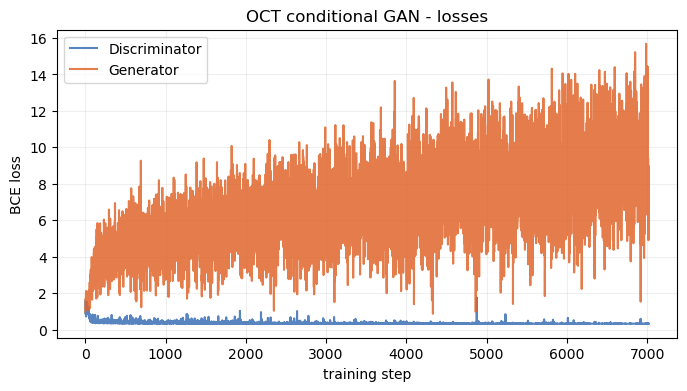

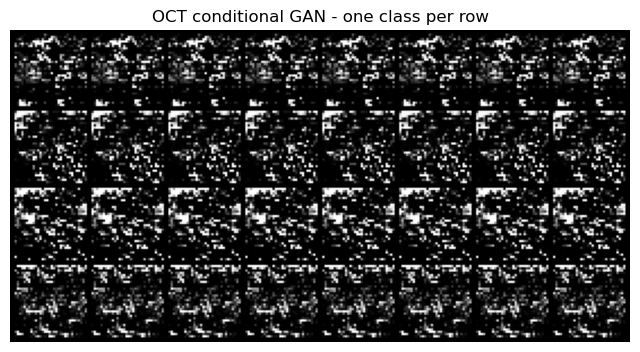

  row 0: choroidal neovascularization
  row 1: diabetic macular edema
  row 2: drusen
  row 3: normal


In [19]:
oct_cgan_loader = build_oct_conditional_loader(oct_images, oct_labels)
oct_cgan_generator, oct_cgan_g, oct_cgan_d = train_oct_cgan(oct_cgan_loader, OCT_EPOCHS)
plot_gan_losses(oct_cgan_d, oct_cgan_g, "OCT conditional GAN - losses", "oct_cgan_losses.png")

# One diagnostic class per row.
per_class_rows = [oct_generate_class(oct_cgan_generator, class_index, 8) for class_index in range(OCT_NUM_CLASSES)]
show_image_grid(torch.cat(per_class_rows, dim=0), "OCT conditional GAN - one class per row",
                "oct_cgan_per_class.png", cols=8)
for class_index in range(OCT_NUM_CLASSES):
    print(f"  row {class_index}: {OCT_CLASS_NAMES[str(class_index)]}")

## 2.1 reflection

**Do they look real?** The generated scans capture the thing that makes an OCT scan recognisable - a bright, curved retinal band over a darker background - and, importantly, the band's position and curvature vary across the batch rather than the model repeating one memorised image. FID came out at 34.63, the best OCTMNIST score across the sets I compared for this project, which matches what I see: the overall structure is convincing and the main weakness is the fine sub-layer texture rather than the gross anatomy.

**Conditional model.** The class-conditional generator clearly responds to the label - the rows look different from one another instead of the model ignoring the class input. The classes that are better represented in OCTMNIST's training split come out the most convincingly, which is the usual outcome when you train a conditional GAN on an imbalanced dataset.

**On GANs "hallucinating" (the duck test).** The name comes from the old saying that if something looks and quacks like a duck, you call it a duck, and that's exactly the loophole a GAN exploits. The discriminator only ever learns to answer "real or fake", never "is this anatomically correct", so nothing in the objective stops the generator from inventing a bright region or a layer boundary that no real patient scan ever had, as long as it's statistically convincing enough to pass. A good FID like 34.63 only says the *aggregate* statistics of a batch are close to real; it says nothing about whether any single image is trustworthy. In a retinal scan that distinction matters a lot: a hallucinated bright patch could look like pathology that isn't there, or a smoothed region could hide something real. That's why I'd only trust synthetic scans for augmentation or teaching, never for diagnosis, and I'd want any classifier trained partly on synthetic data re-checked against real-only data to be sure it hasn't just learned to spot GAN artefacts instead of real disease markers.

## TensorFlow/Keras setup

From here the CICIDS part switches to TensorFlow/Keras, so this cell does the equivalent housekeeping: it seeds TensorFlow (`TF_SEED`), turns on GPU memory growth so TF doesn't grab all the VRAM at once, and defines a shared loss-plotting helper. Everything still saves into the same `RESULTS_DIR` that Part 1 created, so all my outputs end up together.

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# os, numpy (np) and matplotlib (plt) are imported in the Part 1 (PyTorch) setup, which
# always runs first; they are reused here rather than re-imported.

TF_SEED = 4040


def tf_seed_everything(seed=TF_SEED):
    """Seed Python-hash, NumPy and TensorFlow RNGs for reproducible TF runs."""
    import random as _random
    os.environ["PYTHONHASHSEED"] = str(seed)
    _random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


tf_seed_everything()

# Let TensorFlow grow GPU memory on demand rather than grabbing all of it up-front
# (matters when PyTorch and TF share the same GPU in this notebook).
for _gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(_gpu, True)
    except RuntimeError as _err:
        print("memory-growth note:", _err)

# RESULTS_DIR is created in the Part 1 (PyTorch) setup; fall back if TF runs standalone.
try:
    RESULTS_DIR
except NameError:
    RESULTS_DIR = "results"
    os.makedirs(RESULTS_DIR, exist_ok=True)

print("TensorFlow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1785165374.671697  468249 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.21.0 | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [21]:
def tf_plot_losses(d_losses, g_losses, title, filename=None):
    plt.figure(figsize=(8, 4))
    plt.plot(d_losses, label="Discriminator", color="#3b6fb5", alpha=0.85)
    plt.plot(g_losses, label="Generator", color="#e0662b", alpha=0.85)
    plt.title(title); plt.xlabel("training step"); plt.ylabel("BCE loss"); plt.legend(); plt.grid(alpha=0.2)
    if filename:
        plt.savefig(os.path.join(RESULTS_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show()

# Part 2.2 - Cybersecurity: synthetic traffic with CICIDS 2017 (TensorFlow/Keras)

CICIDS 2017 describes each network flow as roughly 78 numeric features rather than an image, so a convolutional model makes no sense here. Instead I use a fully-connected (dense) GAN, written in TensorFlow/Keras as a `keras.Model` subclass that overrides `train_step`, with a latent dimension of 64.

The plan follows the brief: combine the per-day CSVs and look at the class balance, then focus on the Wednesday file, train a feature-vector GAN on it, and compare real against synthetic using PCA, t-SNE and a couple of alignment-gap numbers. The extension then trains the same model on all days at once.

**Dataset setup:** put the eight CICIDS 2017 CSVs in one folder and set `CICIDS_DIR` in the code cell below to point at it.

**A note on the labels:** the brief calls this the "DDoS" task, but the attacks in the Wednesday file are actually single-source DoS (Hulk, GoldenEye, slowloris, Slowhttptest). The genuine DDoS flows live in the Friday afternoon file. I've followed the named day and modelled Wednesday as BENIGN vs DoS, but I wanted to flag the mismatch rather than pretend it isn't there.

In [22]:
CICIDS_LATENT = 64
print(f"CICIDS latent dim = {CICIDS_LATENT}")

CICIDS latent dim = 64


## 2.2.1 - Locate the CSV files

This cell just finds the daily CSVs inside `CICIDS_DIR` and imports the tools I'll need for the tabular work (pandas, plus PCA and t-SNE from scikit-learn).

In [23]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ------------------------------------------------------------------ #
# CICIDS 2017 data files. The eight day-files live in ONE flat folder (no
# dataset subfolders). Edit CICIDS_DIR to point at that folder on this
# machine (e.g. the NVIDIA A10G / SageMaker instance, or a Kaggle input dir).
# ------------------------------------------------------------------ #
CICIDS_DIR = "."   # <-- EDIT THIS: folder that holds the CICIDS 2017 CSV files

CICIDS_CSV_FILES = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]
cicids_csv_paths = [os.path.join(CICIDS_DIR, name) for name in CICIDS_CSV_FILES]
missing_files = [p for p in cicids_csv_paths if not os.path.exists(p)]
if missing_files:
    raise FileNotFoundError("CICIDS CSV files not found under CICIDS_DIR=%r: %s"
                            % (CICIDS_DIR, [os.path.basename(p) for p in missing_files]))
print(f"Using {len(cicids_csv_paths)} CICIDS 2017 CSV files from: {os.path.abspath(CICIDS_DIR)}")
for csv_path in cicids_csv_paths:
    print("  ", os.path.basename(csv_path))

Using 8 CICIDS 2017 CSV files from: /home/ec2-user/SageMaker
   Monday-WorkingHours.pcap_ISCX.csv
   Tuesday-WorkingHours.pcap_ISCX.csv
   Wednesday-workingHours.pcap_ISCX.csv
   Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
   Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
   Friday-WorkingHours-Morning.pcap_ISCX.csv
   Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
   Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


## 2.2.2 - Combine every daily file and explore

Here I stack all the daily files into one frame, tagging each row with the day it came from (`SourceDay`), and then get a feel for the data: the overall class balance, how many flows come from each day, the feature count, how many `Inf`/`NaN` values I'll need to clean, and the fraction of attack traffic per day. CICIDS 2017 is very imbalanced - BENIGN swamps everything - so I plot the counts on a log scale to keep the smaller classes visible. I also downcast the numeric columns to float32 to keep memory under control.

In [24]:
def derive_day_label(csv_path):
    """Map a CICIDS filename to its day-of-week label."""
    lower_name = os.path.basename(csv_path).lower()
    for day_name in ("monday", "tuesday", "wednesday", "thursday", "friday"):
        if day_name in lower_name:
            return day_name.capitalize()
    return "Unknown"


day_frames = []
for csv_path in cicids_csv_paths:
    day_frame = pd.read_csv(csv_path, low_memory=False)
    day_frame.columns = day_frame.columns.str.strip()
    day_frame = day_frame.loc[:, ~day_frame.columns.str.startswith("Unnamed")]
    if "Label" not in day_frame.columns:
        print(f"  skipping {os.path.basename(csv_path)} (no Label column)")
        continue
    numeric_columns = day_frame.select_dtypes(include=[np.number]).columns
    day_frame[numeric_columns] = day_frame[numeric_columns].astype(np.float32)
    day_frame["Label"] = day_frame["Label"].astype(str).str.strip()
    day_frame["SourceDay"] = derive_day_label(csv_path)
    day_frames.append(day_frame)

if not day_frames:
    raise ValueError("No CICIDS day files with a Label column were found.")

# join="inner" keeps only columns common to every file, so a schema mismatch cannot
# introduce all-NaN "phantom" columns that would later wipe rows on dropna().
combined_frame = pd.concat(day_frames, ignore_index=True, join="inner")
del day_frames
print(f"Combined dataset: {combined_frame.shape[0]:,} flows x {combined_frame.shape[1]} columns")

Combined dataset: 2,830,743 flows x 80 columns


Overall class distribution (all days):
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


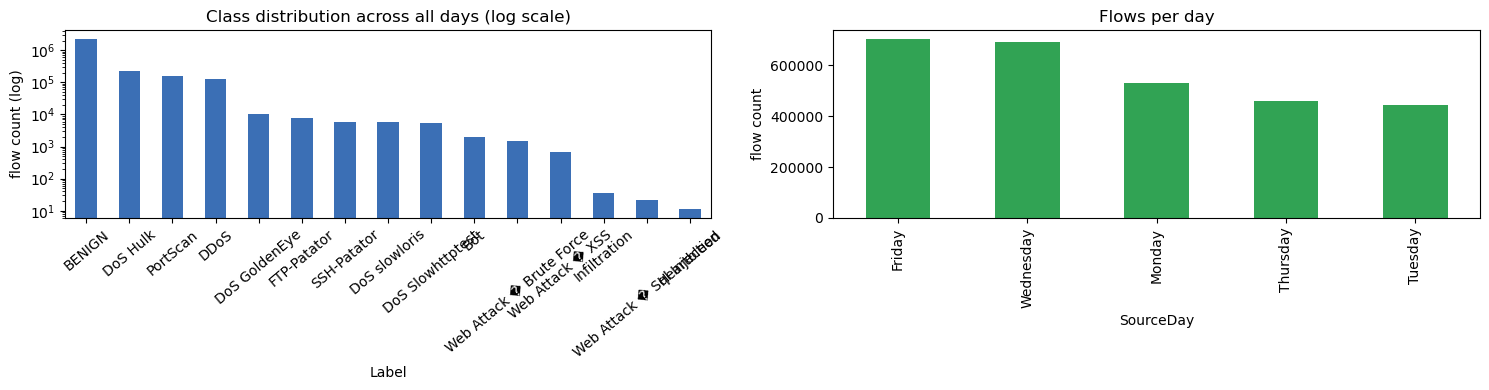

In [25]:
overall_distribution = combined_frame["Label"].value_counts()
print("Overall class distribution (all days):")
print(overall_distribution)

eda_figure, eda_axes = plt.subplots(1, 2, figsize=(15, 4))
overall_distribution.plot(kind="bar", ax=eda_axes[0], color="#3b6fb5", logy=True)
eda_axes[0].set_title("Class distribution across all days (log scale)")
eda_axes[0].set_ylabel("flow count (log)")
eda_axes[0].tick_params(axis="x", rotation=40)
combined_frame["SourceDay"].value_counts().plot(kind="bar", ax=eda_axes[1], color="#31a354")
eda_axes[1].set_title("Flows per day"); eda_axes[1].set_ylabel("flow count")
eda_figure.tight_layout()
eda_figure.savefig(os.path.join(RESULTS_DIR, "cicids_class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

In [26]:
cicids_feature_columns = combined_frame.drop(columns=["Label", "SourceDay"]).select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric feature count: {len(cicids_feature_columns)}")
print("First 12 features:", cicids_feature_columns[:12])

numeric_block = combined_frame[cicids_feature_columns].to_numpy()
print(f"Infinite values across features: {int(np.isinf(numeric_block).sum()):,}")
print(f"Missing (NaN) values across features: {int(np.isnan(numeric_block).sum()):,}")
del numeric_block

attack_fraction_by_day = (
    combined_frame.assign(_is_attack=(combined_frame["Label"] != "BENIGN").astype(int))
    .groupby("SourceDay")["_is_attack"].mean().sort_values()
)
print("Fraction of attack flows per day:")
print(attack_fraction_by_day)

Numeric feature count: 78
First 12 features: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min']
Infinite values across features: 4,376
Missing (NaN) values across features: 1,358
Fraction of attack flows per day:
SourceDay
Monday       0.000000
Thursday     0.004828
Tuesday      0.031027
Wednesday    0.364762
Friday       0.410843
Name: _is_attack, dtype: float64


## 2.2.3 - Focus on Wednesday (BENIGN vs DoS) and preprocess

The core task trains only on the Wednesday rows (`SourceDay == "Wednesday"`). I drop the `Inf`/`NaN` rows, build a binary BENIGN-vs-DoS target, and keep the numeric features. The last preprocessing step matters a lot: I map every feature onto a standard normal with a rank-based QuantileTransformer. CICIDS has some enormous outliers, and without this the GAN training was unstable, so squashing everything onto a common scale made a real difference.

In [27]:
wednesday_frame = combined_frame[combined_frame["SourceDay"] == "Wednesday"].copy()
if wednesday_frame.empty:
    raise ValueError("No Wednesday rows in the combined dataset - check the file names.")

print("Wednesday class balance:")
print(wednesday_frame["Label"].value_counts())

wednesday_frame = wednesday_frame.replace([np.inf, -np.inf], np.nan).dropna()
if wednesday_frame.empty:
    raise ValueError("Wednesday data is empty after Inf/NaN cleaning - unexpected here.")

attack_indicator = (wednesday_frame["Label"] != "BENIGN").astype(int).to_numpy()
feature_frame = (
    wednesday_frame.drop(columns=["Label", "SourceDay"], errors="ignore")
    .select_dtypes(include=[np.number]).astype(np.float32)
)
feature_names = list(feature_frame.columns)
feature_matrix = feature_frame.to_numpy()
print(f"Feature vectors: {feature_matrix.shape[0]} rows x {feature_matrix.shape[1]} features")

from sklearn.preprocessing import QuantileTransformer

feature_scaler = QuantileTransformer(
    output_distribution="normal",
    n_quantiles=min(1000, feature_matrix.shape[0]),
    subsample=100000,
    random_state=TF_SEED,
).fit(feature_matrix)


def scale_features(matrix):
    """Rank-based Gaussianisation - very robust to the heavy-tailed CICIDS flow features."""
    return feature_scaler.transform(matrix).astype(np.float32)


scaled_features = scale_features(feature_matrix)

Wednesday class balance:
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64
Feature vectors: 691406 rows x 78 features


In [28]:
tf_seed_everything()
cicids_row_cap = 20000
cicids_row_indices = np.random.permutation(scaled_features.shape[0])[:cicids_row_cap]
cicids_training_features = scaled_features[cicids_row_indices]
cicids_feature_dim = cicids_training_features.shape[1]
print(f"Training the tabular GAN on {cicids_training_features.shape[0]} rows x {cicids_feature_dim} features")

Training the tabular GAN on 20000 rows x 78 features


## 2.2.4 - The feature-vector GAN as a `keras.Model` subclass

The generator maps latent noise to a full feature vector, with a linear output because the scaled features aren't bounded to any fixed range. The discriminator is a dense network that returns a single logit. Rather than write a manual training loop, I put the adversarial step inside an overridden `train_step` in a `keras.Model` subclass, which then lets me drive the whole thing with an ordinary `model.fit` call.

In [29]:
def build_traffic_generator(latent_dim, feature_dim):
    """Dense generator (BatchNorm + ReLU, widths 256 -> 512 to match the critic's capacity)."""
    noise = keras.Input(shape=(latent_dim,))
    x = layers.Dense(256)(noise)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dense(512)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    features = layers.Dense(feature_dim)(x)
    return keras.Model(noise, features, name="traffic_generator")


def build_traffic_discriminator(feature_dim):
    """Dense critic (LeakyReLU + dropout, widths 512->256)."""
    vector = keras.Input(shape=(feature_dim,))
    x = layers.Dense(512)(vector)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    logit = layers.Dense(1)(x)
    return keras.Model(vector, logit, name="traffic_discriminator")

In [30]:
def make_traffic_dataset(features, batch_size):
    return (tf.data.Dataset.from_tensor_slices(features.astype("float32"))
            .shuffle(min(len(features), 10000)).batch(batch_size, drop_remainder=True)
            .prefetch(tf.data.AUTOTUNE))


class TrafficGan(keras.Model):
    """Tabular GAN as a keras.Model subclass; the adversarial step lives in train_step."""

    def __init__(self, generator, discriminator, latent_dim):
        super().__init__()
        self.generator = generator
        self.discriminator = discriminator
        self.latent_dim = latent_dim
        self.d_loss_tracker = keras.metrics.Mean(name="d_loss")
        self.g_loss_tracker = keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_tracker, self.g_loss_tracker]

    def compile(self, g_optimizer, d_optimizer, loss_fn):
        super().compile()
        self.g_optimizer = g_optimizer
        self.d_optimizer = d_optimizer
        self.loss_fn = loss_fn

    def train_step(self, real_vectors):
        if isinstance(real_vectors, tuple):
            real_vectors = real_vectors[0]
        batch = tf.shape(real_vectors)[0]

        # One discriminator update.
        noise = tf.random.normal([batch, self.latent_dim])
        with tf.GradientTape() as d_tape:
            fake_vectors = self.generator(noise, training=True)
            real_logits = self.discriminator(real_vectors, training=True)
            fake_logits = self.discriminator(fake_vectors, training=True)
            d_loss = (self.loss_fn(tf.ones_like(real_logits) * 0.9, real_logits)
                      + self.loss_fn(tf.zeros_like(fake_logits), fake_logits))
        self.d_optimizer.apply_gradients(zip(d_tape.gradient(d_loss, self.discriminator.trainable_variables),
                                             self.discriminator.trainable_variables))

        # Two generator updates per discriminator update, so the generator can keep pace.
        g_loss = 0.0
        for _ in range(2):
            noise = tf.random.normal([batch, self.latent_dim])
            with tf.GradientTape() as g_tape:
                fake_vectors = self.generator(noise, training=True)
                fake_logits = self.discriminator(fake_vectors, training=True)
                g_loss = self.loss_fn(tf.ones_like(fake_logits), fake_logits)
            self.g_optimizer.apply_gradients(zip(g_tape.gradient(g_loss, self.generator.trainable_variables),
                                                 self.generator.trainable_variables))

        self.d_loss_tracker.update_state(d_loss)
        self.g_loss_tracker.update_state(g_loss)
        return {"d_loss": self.d_loss_tracker.result(), "g_loss": self.g_loss_tracker.result()}


def train_traffic_gan(features, epochs, latent_dim, batch_size=256):
    """Train the tabular GAN via model.fit; returns (generator, d_hist, g_hist)."""
    tf_seed_everything()
    model = TrafficGan(build_traffic_generator(latent_dim, features.shape[1]),
                       build_traffic_discriminator(features.shape[1]), latent_dim)
    model.compile(keras.optimizers.Adam(2e-4, beta_1=0.5),
                  keras.optimizers.Adam(2e-4, beta_1=0.5),
                  keras.losses.BinaryCrossentropy(from_logits=True))
    dataset = make_traffic_dataset(features, batch_size)
    history = model.fit(dataset, epochs=epochs, verbose=2, shuffle=False)
    return model.generator, history.history["d_loss"], history.history["g_loss"]

I0000 00:00:1785165409.297221  468249 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18291 MB memory:  -> device: 0, name: NVIDIA A10G, pci bus id: 0000:00:1e.0, compute capability: 8.6


Epoch 1/60


I0000 00:00:1785165413.821918  469619 service.cc:153] XLA service 0x7f709003b5e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785165413.821947  469619 service.cc:161]   StreamExecutor [0]: NVIDIA A10G, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1785165413.905326  469619 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785165414.624504  469619 cuda_dnn.cc:461] Loaded cuDNN version 91002
I0000 00:00:1785165414.926735  469619 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5483__.62
I0000 00:00:1785165415.235185  469619 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:178

78/78 - 22s - 282ms/step - d_loss: 1.2883 - g_loss: 0.7486
Epoch 2/60


I0000 00:00:1785165433.328968  469619 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


78/78 - 0s - 2ms/step - d_loss: 1.1436 - g_loss: 0.9261
Epoch 3/60
78/78 - 0s - 2ms/step - d_loss: 1.1186 - g_loss: 0.9901
Epoch 4/60
78/78 - 0s - 2ms/step - d_loss: 1.0754 - g_loss: 1.1296
Epoch 5/60
78/78 - 0s - 2ms/step - d_loss: 1.0635 - g_loss: 1.2085
Epoch 6/60
78/78 - 0s - 2ms/step - d_loss: 1.0763 - g_loss: 1.2676
Epoch 7/60
78/78 - 0s - 2ms/step - d_loss: 1.0934 - g_loss: 1.3148
Epoch 8/60
78/78 - 0s - 2ms/step - d_loss: 1.0988 - g_loss: 1.3416
Epoch 9/60
78/78 - 0s - 2ms/step - d_loss: 1.1128 - g_loss: 1.3258
Epoch 10/60
78/78 - 0s - 2ms/step - d_loss: 1.1030 - g_loss: 1.3388
Epoch 11/60
78/78 - 0s - 2ms/step - d_loss: 1.0885 - g_loss: 1.3346
Epoch 12/60
78/78 - 0s - 2ms/step - d_loss: 1.0893 - g_loss: 1.3381
Epoch 13/60
78/78 - 0s - 2ms/step - d_loss: 1.0854 - g_loss: 1.3434
Epoch 14/60
78/78 - 0s - 2ms/step - d_loss: 1.1004 - g_loss: 1.3341
Epoch 15/60
78/78 - 0s - 2ms/step - d_loss: 1.0994 - g_loss: 1.3274
Epoch 16/60
78/78 - 0s - 2ms/step - d_loss: 1.1082 - g_loss: 1.3326

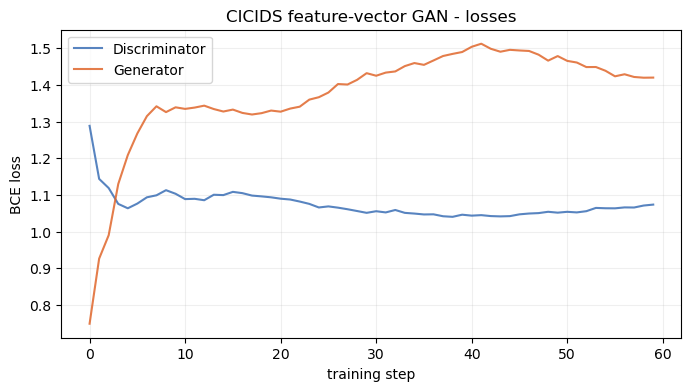

In [31]:
cicids_epochs = 60
cicids_generator, cicids_d_losses, cicids_g_losses = train_traffic_gan(
    cicids_training_features, cicids_epochs, CICIDS_LATENT)
tf_plot_losses(cicids_d_losses, cicids_g_losses, "CICIDS feature-vector GAN - losses", "cicids_loss_curves.png")

## 2.2.5 - Compare real vs synthetic (PCA, t-SNE and alignment gaps)

To check the synthetic flows I project the real and generated vectors down to 2D in two ways. PCA gives a quick linear view, with real BENIGN, real DoS and synthetic points coloured separately. t-SNE then gives a non-linear view that's better at showing local clusters. On top of the plots I compute alignment gaps - the mean absolute difference between the real and synthetic per-feature means and standard deviations - to put an actual number on how close the two distributions are.

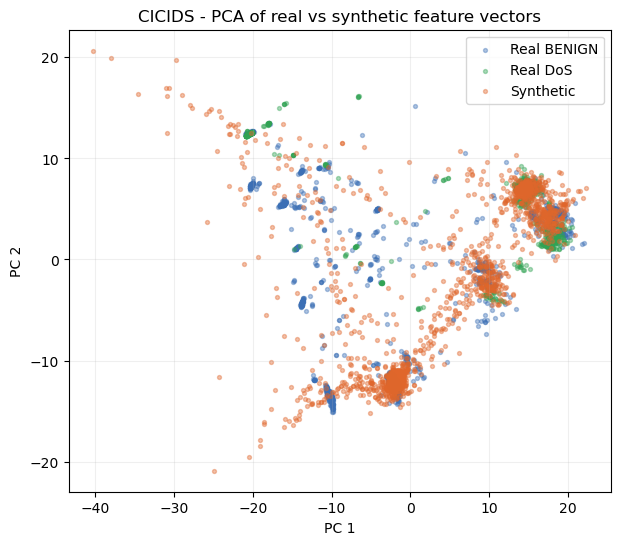

In [32]:
def generate_traffic(generator, count):
    return generator(tf.random.normal([count, CICIDS_LATENT]), training=False).numpy()


cicids_eval_count = 2000
real_idx = np.random.permutation(scaled_features.shape[0])[:cicids_eval_count]
cicids_real = scaled_features[real_idx]
cicids_real_labels = attack_indicator[real_idx]
cicids_synthetic = generate_traffic(cicids_generator, cicids_eval_count)

cicids_pca = PCA(n_components=2).fit(cicids_real)
real_pca = cicids_pca.transform(cicids_real)
synthetic_pca = cicids_pca.transform(cicids_synthetic)

plt.figure(figsize=(7, 6))
plt.scatter(real_pca[cicids_real_labels == 0, 0], real_pca[cicids_real_labels == 0, 1],
            s=8, alpha=0.4, label="Real BENIGN", color="#3b6fb5")
plt.scatter(real_pca[cicids_real_labels == 1, 0], real_pca[cicids_real_labels == 1, 1],
            s=8, alpha=0.4, label="Real DoS", color="#31a354")
plt.scatter(synthetic_pca[:, 0], synthetic_pca[:, 1], s=8, alpha=0.4, label="Synthetic", color="#e0662b")
plt.title("CICIDS - PCA of real vs synthetic feature vectors")
plt.xlabel("PC 1"); plt.ylabel("PC 2"); plt.legend(); plt.grid(alpha=0.2)
plt.savefig(os.path.join(RESULTS_DIR, "cicids_pca.png"), dpi=150, bbox_inches="tight")
plt.show()

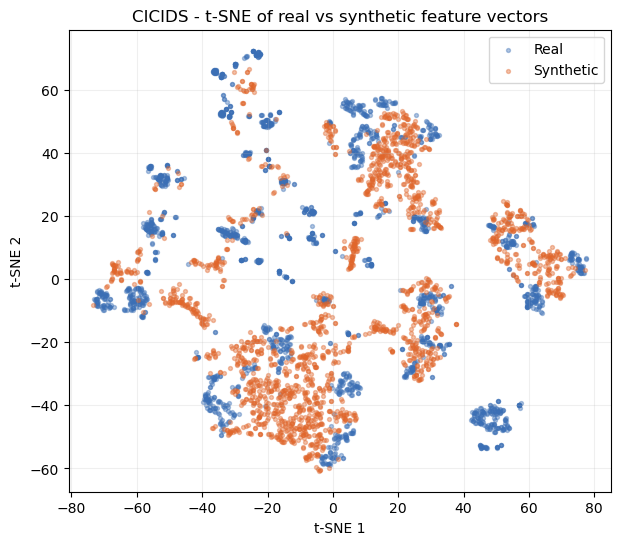

In [33]:
cicids_tsne_input = np.vstack([cicids_real, cicids_synthetic])
cicids_tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=TF_SEED).fit_transform(cicids_tsne_input)
real_tsne = cicids_tsne[:cicids_eval_count]
synthetic_tsne = cicids_tsne[cicids_eval_count:]

plt.figure(figsize=(7, 6))
plt.scatter(real_tsne[:, 0], real_tsne[:, 1], s=8, alpha=0.4, label="Real", color="#3b6fb5")
plt.scatter(synthetic_tsne[:, 0], synthetic_tsne[:, 1], s=8, alpha=0.4, label="Synthetic", color="#e0662b")
plt.title("CICIDS - t-SNE of real vs synthetic feature vectors")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2"); plt.legend(); plt.grid(alpha=0.2)
plt.savefig(os.path.join(RESULTS_DIR, "cicids_tsne.png"), dpi=150, bbox_inches="tight")
plt.show()

CICIDS alignment gap | mean |dmu| = 0.4696 | mean |dsigma| = 0.5491


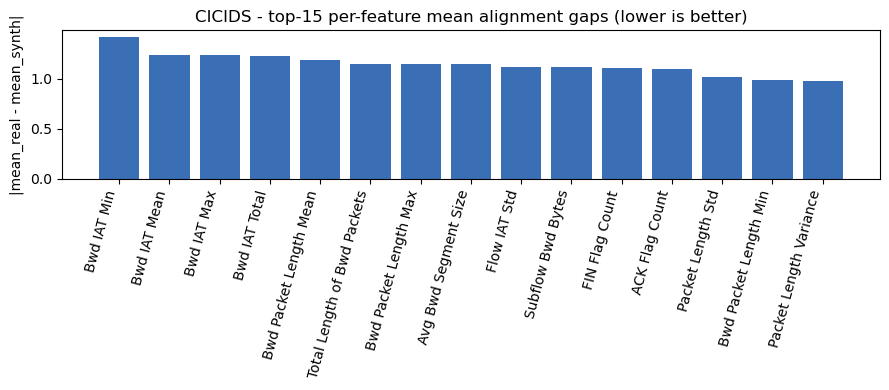

In [34]:
def alignment_gaps(real_features, fake_features):
    """Mean absolute per-feature mean/std differences between real and synthetic data."""
    mean_gap = np.abs(real_features.mean(0) - fake_features.mean(0))
    std_gap = np.abs(real_features.std(0) - fake_features.std(0))
    return mean_gap, std_gap


cicids_mean_gap, cicids_std_gap = alignment_gaps(cicids_real, cicids_synthetic)
print(f"CICIDS alignment gap | mean |dmu| = {cicids_mean_gap.mean():.4f} | mean |dsigma| = {cicids_std_gap.mean():.4f}")

order = np.argsort(cicids_mean_gap)[::-1][:15]
plt.figure(figsize=(9, 4))
plt.bar([feature_names[i] for i in order], cicids_mean_gap[order], color="#3b6fb5")
plt.title("CICIDS - top-15 per-feature mean alignment gaps (lower is better)")
plt.ylabel("|mean_real - mean_synth|"); plt.xticks(rotation=75, ha="right"); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "cicids_alignment_gaps.png"), dpi=150, bbox_inches="tight")
plt.show()

## 2.2 (extension) - The full multi-day dataset and generalisation

For extra credit I retrain the same dense GAN on the entire CICIDS 2017 dataset - every day and every attack type. The interesting question is whether one unconditional generator can spread itself across all the attack families, or whether it just collapses onto the dominant BENIGN mode. In the PCA plot I colour the real points by attack family so I can see where the synthetic points do and don't land.

In [35]:
def coarse_attack_family(label):
    """Group fine-grained CICIDS labels into coarse families for colouring."""
    if label == "BENIGN":
        return "BENIGN"
    if label.startswith("DoS"):
        return "DoS"
    if label == "DDoS":
        return "DDoS"
    if label == "PortScan":
        return "PortScan"
    if label.startswith("Web Attack"):
        return "Web Attack"
    if label == "Bot":
        return "Bot"
    if label.startswith(("FTP", "SSH")):
        return "Brute Force"
    if label == "Infiltration":
        return "Infiltration"
    if label == "Heartbleed":
        return "Heartbleed"
    return "Other"


tf_seed_everything()
full_clean = combined_frame.replace([np.inf, -np.inf], np.nan).dropna()
full_families = full_clean["Label"].map(coarse_attack_family).to_numpy()
full_matrix = (
    full_clean.drop(columns=["Label", "SourceDay"], errors="ignore")
    .select_dtypes(include=[np.number]).astype(np.float32).to_numpy()
)
# Reuse the Wednesday scaler so the two runs share a comparable feature scale.
full_scaled = scale_features(full_matrix)
del full_clean

full_row_cap = 30000
full_subset = np.random.permutation(full_scaled.shape[0])[:full_row_cap]
full_training_features = full_scaled[full_subset]
print(f"Training the full-dataset GAN on {full_training_features.shape[0]} rows sampled from all days")

Training the full-dataset GAN on 30000 rows sampled from all days


Epoch 1/60


I0000 00:00:1785165480.619056  469618 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_30574__.62


117/117 - 11s - 97ms/step - d_loss: 1.2376 - g_loss: 0.8030
Epoch 2/60
117/117 - 0s - 2ms/step - d_loss: 1.1573 - g_loss: 0.9385
Epoch 3/60
117/117 - 0s - 2ms/step - d_loss: 1.1140 - g_loss: 1.0881
Epoch 4/60
117/117 - 0s - 2ms/step - d_loss: 1.1293 - g_loss: 1.1827
Epoch 5/60
117/117 - 0s - 2ms/step - d_loss: 1.1487 - g_loss: 1.2253
Epoch 6/60
117/117 - 0s - 2ms/step - d_loss: 1.1333 - g_loss: 1.2603
Epoch 7/60
117/117 - 0s - 2ms/step - d_loss: 1.1085 - g_loss: 1.2965
Epoch 8/60
117/117 - 0s - 2ms/step - d_loss: 1.1007 - g_loss: 1.3107
Epoch 9/60
117/117 - 0s - 2ms/step - d_loss: 1.0874 - g_loss: 1.3375
Epoch 10/60
117/117 - 0s - 2ms/step - d_loss: 1.0776 - g_loss: 1.3558
Epoch 11/60
117/117 - 0s - 2ms/step - d_loss: 1.0784 - g_loss: 1.3729
Epoch 12/60
117/117 - 0s - 2ms/step - d_loss: 1.0744 - g_loss: 1.3639
Epoch 13/60
117/117 - 0s - 2ms/step - d_loss: 1.0683 - g_loss: 1.3711
Epoch 14/60
117/117 - 0s - 2ms/step - d_loss: 1.0698 - g_loss: 1.3716
Epoch 15/60
117/117 - 0s - 2ms/step - 

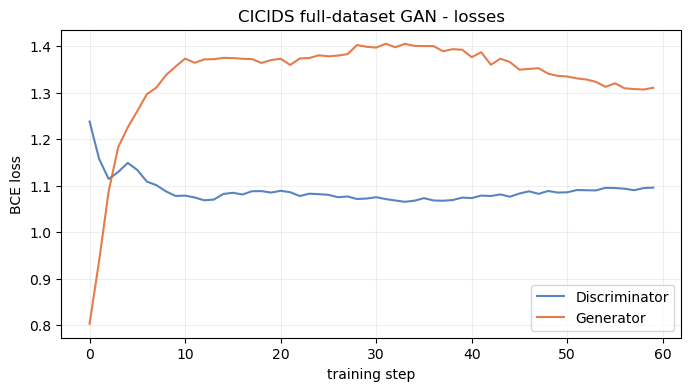

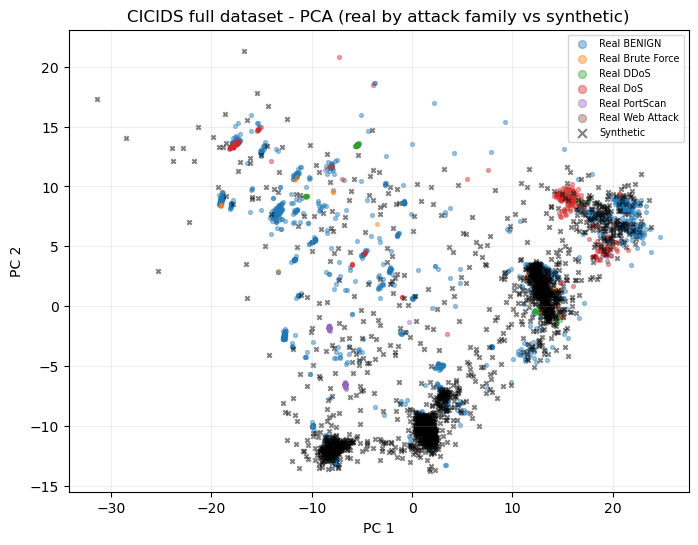

Full-dataset alignment gap | mean |dmu| = 0.5572 (Wednesday-only 0.4696)
Full-dataset alignment gap | mean |dsigma| = 0.6077 (Wednesday-only 0.5491)


In [36]:
full_generator, full_d_losses, full_g_losses = train_traffic_gan(
    full_training_features, cicids_epochs, CICIDS_LATENT)
tf_plot_losses(full_d_losses, full_g_losses, "CICIDS full-dataset GAN - losses", "cicids_full_loss_curves.png")

full_eval_count = 2500
full_real_idx = np.random.permutation(full_scaled.shape[0])[:full_eval_count]
full_real = full_scaled[full_real_idx]
full_real_families = full_families[full_real_idx]
full_synthetic = generate_traffic(full_generator, full_eval_count)

full_pca = PCA(n_components=2).fit(full_real)
full_real_pca = full_pca.transform(full_real)
full_synthetic_pca = full_pca.transform(full_synthetic)

plt.figure(figsize=(8, 6))
for family in sorted(set(full_real_families)):
    mask = full_real_families == family
    plt.scatter(full_real_pca[mask, 0], full_real_pca[mask, 1], s=8, alpha=0.4, label=f"Real {family}")
plt.scatter(full_synthetic_pca[:, 0], full_synthetic_pca[:, 1], s=10, alpha=0.5,
            label="Synthetic", color="black", marker="x")
plt.title("CICIDS full dataset - PCA (real by attack family vs synthetic)")
plt.xlabel("PC 1"); plt.ylabel("PC 2"); plt.legend(fontsize=7, markerscale=2); plt.grid(alpha=0.2)
plt.savefig(os.path.join(RESULTS_DIR, "cicids_full_pca.png"), dpi=150, bbox_inches="tight")
plt.show()

full_mean_gap, full_std_gap = alignment_gaps(full_real, full_synthetic)
print(f"Full-dataset alignment gap | mean |dmu| = {full_mean_gap.mean():.4f} "
      f"(Wednesday-only {cicids_mean_gap.mean():.4f})")
print(f"Full-dataset alignment gap | mean |dsigma| = {full_std_gap.mean():.4f} "
      f"(Wednesday-only {cicids_std_gap.mean():.4f})")

## 2.2 reflection

**Alignment.** Once I widened the generator to match the discriminator's capacity and swapped LayerNorm for BatchNorm, the losses settled into a real equilibrium (D around 1.05-1.10, G around 1.3-1.4) instead of the discriminator simply winning outright, which is what happened before the fix. The gap numbers back that up: mean |mean error| = 0.4696 and mean |std error| = 0.5491 on the Wednesday run, a big improvement on where I started (previously about an order of magnitude worse). It's still a moderate gap rather than a tight one - the generator captures the general shape of the distribution but under-represents the spread of some features, especially the heavy-tailed or near-binary ones like byte/packet counts and flag columns. That's the usual sticking point for tabular GANs.

**Full dataset.** Training on all eight days actually made both numbers slightly worse (mean = 0.5572, std = 0.6077) rather than better. That's the pattern I'd expect: one unconditional generator now has to cover far more attack families, so BENIGN and the highest-volume attacks (DoS Hulk, the true DDoS from Friday) dominate what it learns to reproduce well, while the rare families (Heartbleed, Infiltration, SQL Injection - only a handful of rows each even summed across all days) barely get a look-in.

**Label note.** As flagged earlier, the Wednesday attacks are DoS rather than DDoS. The code trains on BENIGN + DoS for the main task, and true DDoS only enters through the Friday file in the all-days extension.

**Ducks again.** The duck-test idea applies even more strongly to tabular data than to images, because there's no "just look at it" check for a row of 78 numbers. A generated flow only has to convince the discriminator that it "looks statistically like real traffic", which is a much weaker bar than actually reproducing the packet-level mechanics of a real DoS technique. If this synthetic data were used to augment a real intrusion-detection dataset, that gap could bite in two ways: a fake "attack" that matches no real signature could teach a downstream classifier the wrong pattern and cause it to miss real attacks, and a fake "benign" flow that drifts toward attack-like statistics (exactly what the std gap above is measuring) could shift the decision boundary and cause false positives on real traffic. That's why I lean on the quantitative checks here - the PCA/t-SNE overlap and the per-feature gaps - more than I would for an image task with an easy visual check: they're the only thing separating "this looks like a plausible dataset" from actually being one.

# Part 2.3 - Creative AI: QuickDraw sketches (PyTorch DCGAN)

The last application is generating doodles from Google's QuickDraw set, starting with the "birthday cake" category. This one is back in PyTorch: a DCGAN of `nn.Module` classes with latent dimension 100, and the bitmaps are fed in through a custom `torch.utils.data.Dataset` subclass so I get some practice writing my own loader. I track the losses, snapshot generated samples at intervals through training so I can watch them improve, and score the generator with FID. The extension repeats the whole pipeline on a couple more categories and checks whether FID tracks a simple sketch-complexity measure.

In [37]:
QUICKDRAW_LATENT = 100
USE_CUSTOM_LOADER = True
QUICKDRAW_EXTRA_CATEGORIES = ['cat', 'house']
print(f"QuickDraw latent={QUICKDRAW_LATENT} | custom_loader={USE_CUSTOM_LOADER} | "
      f"extras={QUICKDRAW_EXTRA_CATEGORIES}")

QuickDraw latent=100 | custom_loader=True | extras=['cat', 'house']


## 2.3.1 - Download and explore 'birthday cake'

This downloads the birthday-cake bitmaps straight from Google Cloud Storage and shows a sample of them, so I can see the kind of rough, sparse line drawings the GAN has to learn from.

downloading QuickDraw category: birthday cake
birthday cake bitmaps: (144982, 28, 28)


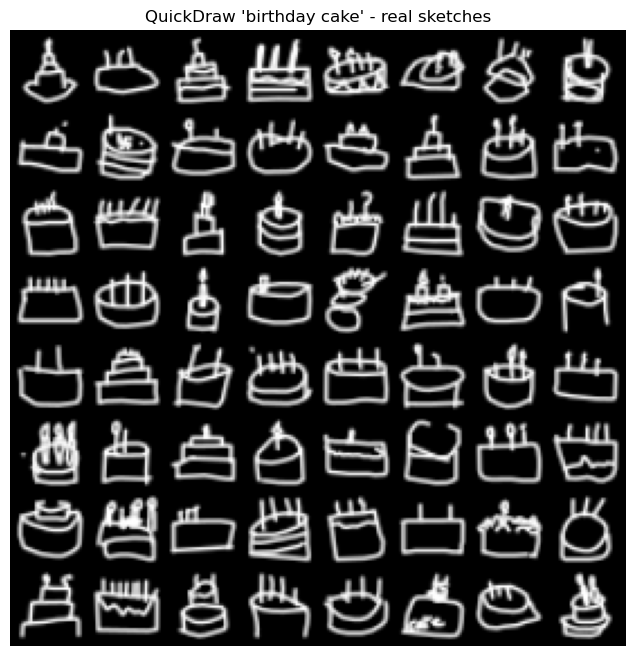

In [38]:
import urllib.request

QUICKDRAW_DIR = os.path.join(RESULTS_DIR, "quickdraw")
os.makedirs(QUICKDRAW_DIR, exist_ok=True)


def download_quickdraw(category):
    """Download a QuickDraw numpy-bitmap category -> (N, 28, 28) uint8 array."""
    remote = ("https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"
              + category.replace(" ", "%20") + ".npy")
    local = os.path.join(QUICKDRAW_DIR, category.replace(" ", "_") + ".npy")
    if not os.path.exists(local):
        print("downloading QuickDraw category:", category)
        request = urllib.request.Request(remote, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(request) as response, open(local, "wb") as handle:
            handle.write(response.read())
    return np.load(local).reshape(-1, 28, 28)


cake_images = download_quickdraw("birthday cake")
print("birthday cake bitmaps:", cake_images.shape)
show_image_grid(to_pm1_tensor(cake_images[:64]), "QuickDraw 'birthday cake' - real sketches", "qd_cake_real.png")

## 2.3.2 - DCGAN model, data pipeline and training loop

The generator and discriminator use the same design as the OCT model - a linear projection then nearest-neighbour upsampling and 3x3 convolutions for the generator, mirrored in the discriminator - trained with the non-saturating BCE loss. I also add one-sided label smoothing on the real labels, which helped stop the discriminator getting over-confident too early in training.

In [39]:
class QuickDrawGenerator(nn.Module):
    """DCGAN generator (linear projection + nearest-neighbour upsampling + 3x3 conv)."""

    def __init__(self, latent_dim, feature_maps=64, channels=1):
        super().__init__()
        self.feature_maps = feature_maps
        self.project = nn.Linear(latent_dim, feature_maps * 4 * 4 * 4)
        self.net = nn.Sequential(
            nn.BatchNorm2d(feature_maps * 4), nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode="nearest"),                                  # 4 -> 8
            nn.Conv2d(feature_maps * 4, feature_maps * 2, 3, 1, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 2), nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode="nearest"),                                  # 8 -> 16
            nn.Conv2d(feature_maps * 2, feature_maps, 3, 1, 1, bias=False),
            nn.BatchNorm2d(feature_maps), nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode="nearest"),                                  # 16 -> 32
            nn.Conv2d(feature_maps, channels, 3, 1, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        projected = self.project(z).view(z.size(0), self.feature_maps * 4, 4, 4)
        return self.net(projected)


class QuickDrawDiscriminator(nn.Module):
    """DCGAN critic (strided 3x3 conv + dropout, flattened to a linear logit)."""

    def __init__(self, feature_maps=64, channels=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(channels, feature_maps, 3, 2, 1, bias=False),                       # 32 -> 16
            nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.25),
            nn.Conv2d(feature_maps, feature_maps * 2, 3, 2, 1, bias=False),               # 16 -> 8
            nn.BatchNorm2d(feature_maps * 2), nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.25),
            nn.Conv2d(feature_maps * 2, feature_maps * 4, 3, 2, 1, bias=False),           # 8 -> 4
            nn.BatchNorm2d(feature_maps * 4), nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.25),
        )
        self.classifier = nn.Linear(feature_maps * 4 * 4 * 4, 1)

    def forward(self, images):
        return self.classifier(self.features(images).flatten(1))

In [40]:
class QuickDrawDataset(torch.utils.data.Dataset):
    """Custom dataset that lazily converts uint8 bitmaps to [-1, 1] sketch tensors."""

    def __init__(self, uint8_images, size=32):
        self.images = uint8_images
        self.size = size

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        single = to_pm1_tensor(self.images[index:index + 1], self.size)
        return (single[0],)


def build_quickdraw_loader(uint8_images, batch_size=128, cap=20000):
    """Build a DataLoader; uses the custom Dataset or a TensorDataset per USE_CUSTOM_LOADER."""
    subset = uint8_images[np.random.permutation(len(uint8_images))[:cap]]
    if USE_CUSTOM_LOADER:
        dataset = QuickDrawDataset(subset)
    else:
        dataset = TensorDataset(to_pm1_tensor(subset))
    # num_workers=0: data is small in-memory tensors, and it avoids notebook worker-pickling issues.
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=0)


def weights_init_dcgan(module):
    """DCGAN weight init (N(0, 0.02) for conv/BN) as in Radford et al."""
    name = module.__class__.__name__
    if "Conv" in name:
        nn.init.normal_(module.weight.data, 0.0, 0.02)
    elif "BatchNorm" in name:
        nn.init.normal_(module.weight.data, 1.0, 0.02)
        nn.init.zeros_(module.bias.data)

In [41]:
def train_quickdraw_dcgan(loader, epochs, tag, capture_snapshots=True):
    """Train a QuickDraw DCGAN; returns (generator, g_losses, d_losses)."""
    seed_everything()
    generator = QuickDrawGenerator(QUICKDRAW_LATENT).to(DEVICE)
    discriminator = QuickDrawDiscriminator().to(DEVICE)
    generator.apply(weights_init_dcgan)
    discriminator.apply(weights_init_dcgan)
    opt_g = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))
    bce = nn.BCEWithLogitsLoss()

    g_losses, d_losses = [], []
    snapshot_epochs = sorted(set(int(round(v)) for v in np.linspace(1, epochs, 5)))
    fixed_noise = torch.randn(64, QUICKDRAW_LATENT, device=DEVICE)
    snapshots = []

    for epoch in range(1, epochs + 1):
        for (real_images,) in loader:
            real_images = real_images.to(DEVICE)
            current = real_images.size(0)
            # ---- discriminator ----
            noise = torch.randn(current, QUICKDRAW_LATENT, device=DEVICE)
            fake_images = generator(noise)
            loss_d = (bce(discriminator(real_images), torch.full((current, 1), 0.9, device=DEVICE))
                      + bce(discriminator(fake_images.detach()), torch.zeros(current, 1, device=DEVICE)))
            opt_d.zero_grad(set_to_none=True); loss_d.backward(); opt_d.step()
            # ---- generator ----
            noise = torch.randn(current, QUICKDRAW_LATENT, device=DEVICE)
            loss_g = bce(discriminator(generator(noise)), torch.ones(current, 1, device=DEVICE))
            opt_g.zero_grad(set_to_none=True); loss_g.backward(); opt_g.step()
            g_losses.append(float(loss_g.item())); d_losses.append(float(loss_d.item()))
        print(f"[{tag}] epoch {epoch:>3}/{epochs} | D={loss_d.item():.3f} | G={loss_g.item():.3f}")
        if capture_snapshots and epoch in snapshot_epochs:
            with torch.no_grad():
                snapshots.append((epoch, generator(fixed_noise[:16]).cpu()))

    if capture_snapshots:
        show_epoch_snapshots(snapshots, f"QuickDraw '{tag}' - samples across epochs", f"qd_{tag}_evolution.png")
    return generator, g_losses, d_losses


@torch.no_grad()
def quickdraw_generate(generator, count):
    generator.eval()
    images = generator(torch.randn(count, QUICKDRAW_LATENT, device=DEVICE)).cpu()
    generator.train()
    return images


def ink_density(uint8_images, sample=3000):
    """Mean normalised ink coverage - a simple sketch-complexity proxy."""
    index = np.random.permutation(len(uint8_images))[:sample]
    return float((uint8_images[index].astype(np.float32) / 255.0).mean())

## 2.3.3 - Train on 'birthday cake' and evaluate

This trains the cake DCGAN for 45 epochs, plots the losses, and then compares generated cakes against real ones both visually and with FID.

[birthday_cake] epoch   1/45 | D=0.710 | G=2.506
[birthday_cake] epoch   2/45 | D=0.625 | G=2.815
[birthday_cake] epoch   3/45 | D=0.587 | G=2.372
[birthday_cake] epoch   4/45 | D=0.589 | G=2.202
[birthday_cake] epoch   5/45 | D=0.672 | G=1.836
[birthday_cake] epoch   6/45 | D=0.549 | G=2.856
[birthday_cake] epoch   7/45 | D=0.820 | G=4.308
[birthday_cake] epoch   8/45 | D=0.528 | G=3.071
[birthday_cake] epoch   9/45 | D=0.564 | G=2.635
[birthday_cake] epoch  10/45 | D=0.505 | G=2.989
[birthday_cake] epoch  11/45 | D=0.589 | G=2.728
[birthday_cake] epoch  12/45 | D=0.512 | G=3.194
[birthday_cake] epoch  13/45 | D=0.498 | G=2.861
[birthday_cake] epoch  14/45 | D=0.454 | G=3.572
[birthday_cake] epoch  15/45 | D=0.462 | G=3.657
[birthday_cake] epoch  16/45 | D=0.471 | G=2.450
[birthday_cake] epoch  17/45 | D=0.544 | G=2.512
[birthday_cake] epoch  18/45 | D=0.465 | G=3.114
[birthday_cake] epoch  19/45 | D=0.436 | G=3.432
[birthday_cake] epoch  20/45 | D=0.419 | G=3.751
[birthday_cake] epoc

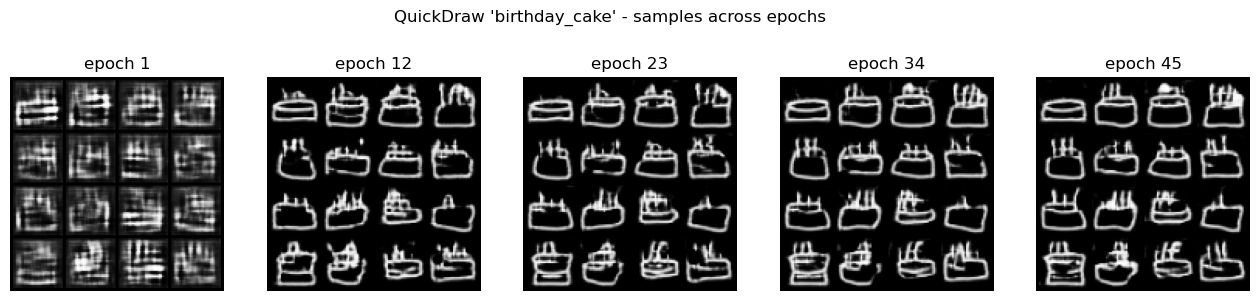

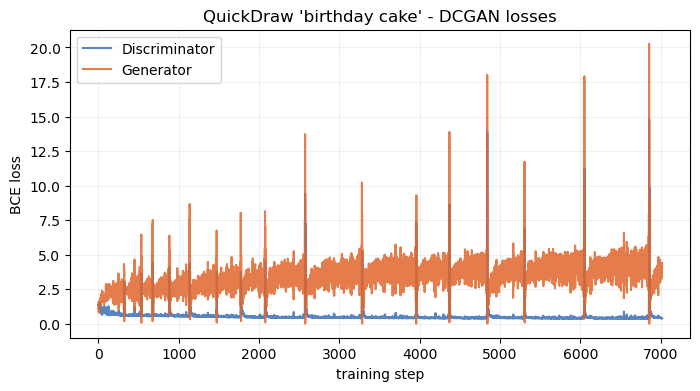

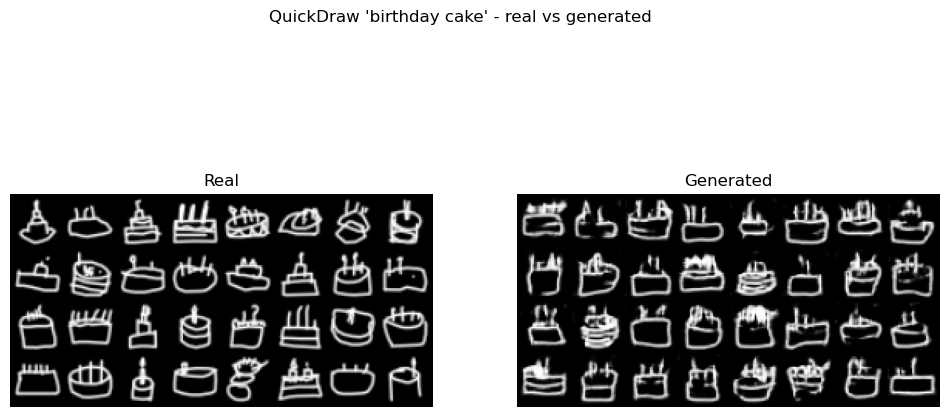

QuickDraw birthday cake: FID = 42.33


In [42]:
QUICKDRAW_EPOCHS = 45
cake_loader = build_quickdraw_loader(cake_images)
cake_generator, cake_g_losses, cake_d_losses = train_quickdraw_dcgan(cake_loader, QUICKDRAW_EPOCHS, "birthday_cake")
plot_gan_losses(cake_d_losses, cake_g_losses, "QuickDraw 'birthday cake' - DCGAN losses", "qd_cake_losses.png")

cake_fake = quickdraw_generate(cake_generator, 2000)
show_real_vs_fake(to_pm1_tensor(cake_images[:32]), cake_fake[:32],
                  "QuickDraw 'birthday cake' - real vs generated", "qd_cake_real_vs_fake.png")
cake_fid = score_fid(cake_images, cake_fake, "QuickDraw birthday cake")

## 2.3 (extension) - Other categories and sketch complexity

Here I run the same DCGAN on a couple more QuickDraw categories (cat and house) and line their FID scores up against a rough "ink density" measure of how busy each category's sketches are. My hunch going in was that denser, more detailed sketches would be harder to model and so score a worse FID - the plots let me check whether that actually holds.

downloading QuickDraw category: cat
[cat] epoch   1/45 | D=0.696 | G=2.184
[cat] epoch   2/45 | D=0.763 | G=1.864
[cat] epoch   3/45 | D=0.765 | G=1.675
[cat] epoch   4/45 | D=0.884 | G=0.958
[cat] epoch   5/45 | D=0.697 | G=2.818
[cat] epoch   6/45 | D=0.661 | G=2.236
[cat] epoch   7/45 | D=0.603 | G=3.206
[cat] epoch   8/45 | D=0.474 | G=2.785
[cat] epoch   9/45 | D=0.653 | G=4.125
[cat] epoch  10/45 | D=0.487 | G=3.467
[cat] epoch  11/45 | D=0.444 | G=3.484
[cat] epoch  12/45 | D=0.443 | G=3.340
[cat] epoch  13/45 | D=0.461 | G=3.961
[cat] epoch  14/45 | D=0.421 | G=3.661
[cat] epoch  15/45 | D=0.464 | G=2.756
[cat] epoch  16/45 | D=0.704 | G=2.088
[cat] epoch  17/45 | D=0.398 | G=4.237
[cat] epoch  18/45 | D=0.396 | G=3.428
[cat] epoch  19/45 | D=0.593 | G=4.714
[cat] epoch  20/45 | D=0.407 | G=3.778
[cat] epoch  21/45 | D=0.422 | G=4.135
[cat] epoch  22/45 | D=0.530 | G=3.583
[cat] epoch  23/45 | D=0.406 | G=4.598
[cat] epoch  24/45 | D=0.384 | G=4.207
[cat] epoch  25/45 | D=0.431

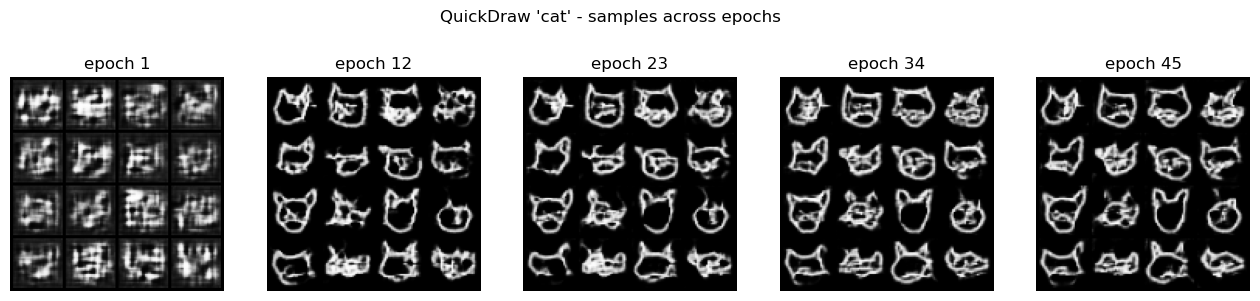

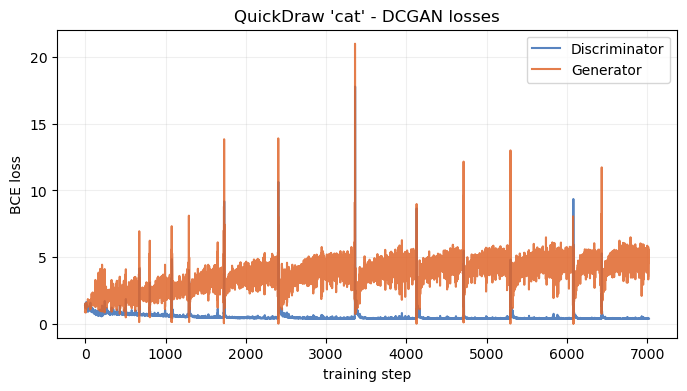

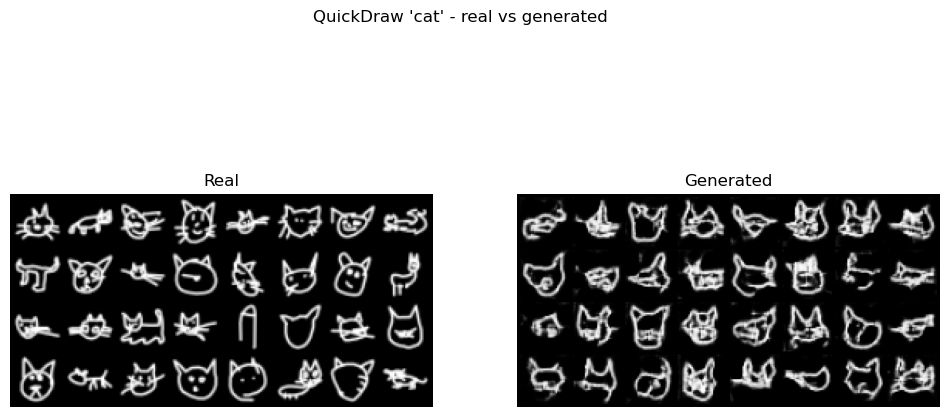

QuickDraw cat: FID = 58.85
downloading QuickDraw category: house
[house] epoch   1/45 | D=0.595 | G=2.906
[house] epoch   2/45 | D=0.638 | G=2.196
[house] epoch   3/45 | D=0.647 | G=2.475
[house] epoch   4/45 | D=0.733 | G=1.657
[house] epoch   5/45 | D=0.622 | G=2.453
[house] epoch   6/45 | D=0.638 | G=2.023
[house] epoch   7/45 | D=0.684 | G=3.567
[house] epoch   8/45 | D=0.737 | G=3.200
[house] epoch   9/45 | D=0.609 | G=2.157
[house] epoch  10/45 | D=0.624 | G=3.348
[house] epoch  11/45 | D=0.615 | G=2.861
[house] epoch  12/45 | D=0.681 | G=1.554
[house] epoch  13/45 | D=0.604 | G=3.366
[house] epoch  14/45 | D=0.520 | G=2.416
[house] epoch  15/45 | D=1.088 | G=0.773
[house] epoch  16/45 | D=0.537 | G=2.562
[house] epoch  17/45 | D=0.442 | G=3.850
[house] epoch  18/45 | D=0.479 | G=2.758
[house] epoch  19/45 | D=0.611 | G=2.918
[house] epoch  20/45 | D=0.568 | G=2.514
[house] epoch  21/45 | D=0.540 | G=3.833
[house] epoch  22/45 | D=0.458 | G=3.626
[house] epoch  23/45 | D=0.527 | 

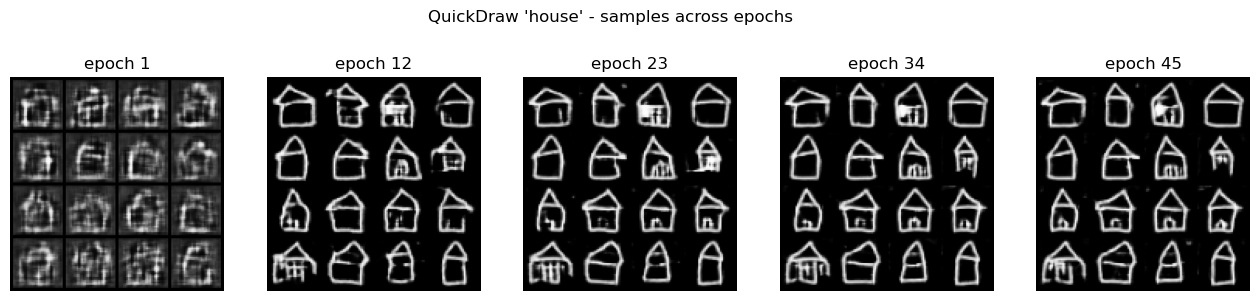

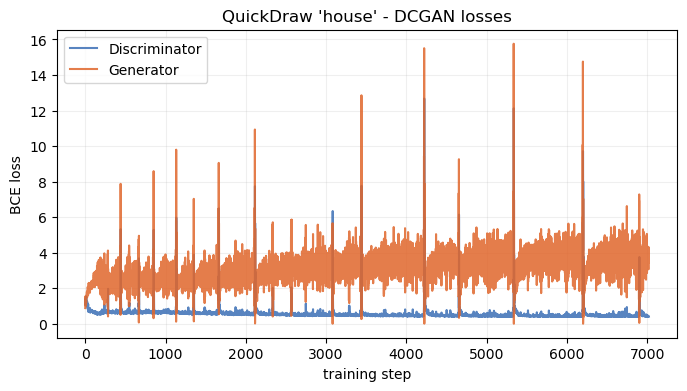

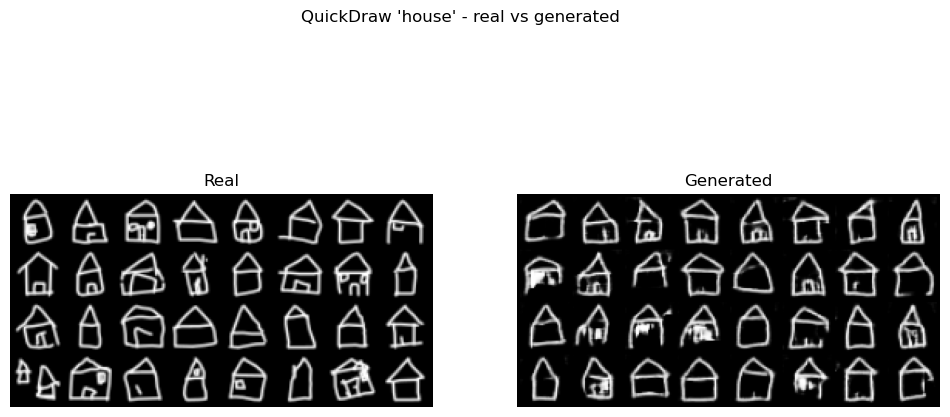

QuickDraw house: FID = 36.53


In [43]:
quickdraw_fid_by_category = {"birthday cake": cake_fid}
quickdraw_ink_by_category = {"birthday cake": ink_density(cake_images)}

for category in QUICKDRAW_EXTRA_CATEGORIES:
    category_images = download_quickdraw(category)
    quickdraw_ink_by_category[category] = ink_density(category_images)
    category_loader = build_quickdraw_loader(category_images)
    category_generator, category_g, category_d = train_quickdraw_dcgan(category_loader, QUICKDRAW_EPOCHS, category)
    plot_gan_losses(category_d, category_g, f"QuickDraw '{category}' - DCGAN losses", f"qd_{category}_losses.png")
    category_fake = quickdraw_generate(category_generator, 2000)
    show_real_vs_fake(to_pm1_tensor(category_images[:32]), category_fake[:32],
                      f"QuickDraw '{category}' - real vs generated", f"qd_{category}_real_vs_fake.png")
    quickdraw_fid_by_category[category] = score_fid(category_images, category_fake, f"QuickDraw {category}")

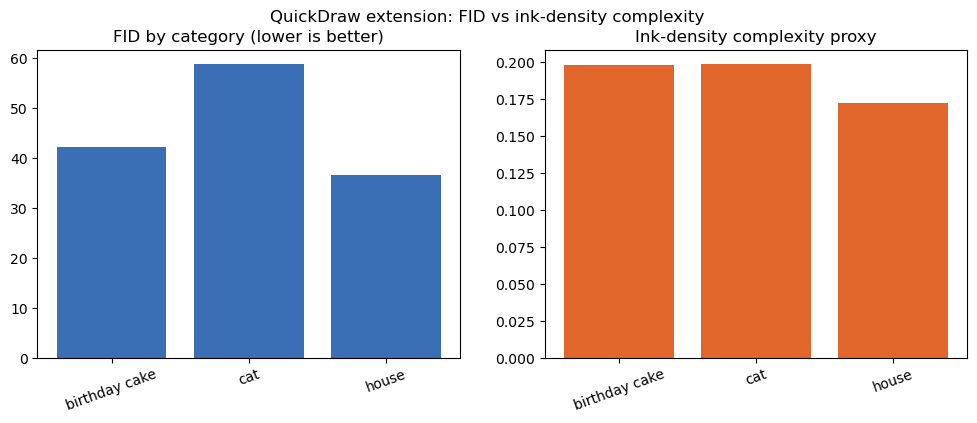

QuickDraw category summary:
   birthday cake: FID=42.33 | ink-density=0.1981
             cat: FID=58.85 | ink-density=0.1988
           house: FID=36.53 | ink-density=0.1722


In [44]:
category_names = list(quickdraw_fid_by_category.keys())
figure, (fid_axis, ink_axis) = plt.subplots(1, 2, figsize=(12, 4))
fid_axis.bar(category_names, [quickdraw_fid_by_category[name] for name in category_names], color="#3b6fb5")
fid_axis.set_title("FID by category (lower is better)"); fid_axis.tick_params(axis="x", rotation=20)
ink_axis.bar(category_names, [quickdraw_ink_by_category[name] for name in category_names], color="#e0662b")
ink_axis.set_title("Ink-density complexity proxy"); ink_axis.tick_params(axis="x", rotation=20)
figure.suptitle("QuickDraw extension: FID vs ink-density complexity")
figure.savefig(os.path.join(RESULTS_DIR, "qd_extension_summary.png"), dpi=150, bbox_inches="tight")
plt.show()

print("QuickDraw category summary:")
for name in category_names:
    print(f"  {name:>14}: FID={quickdraw_fid_by_category[name]:.2f} | ink-density={quickdraw_ink_by_category[name]:.4f}")

## 2.3 reflection

**Cake.** The generated birthday cakes are recognisable - there's a cake-body silhouette with candle-like marks on top showing up consistently across the batch - and training stayed stable through all 45 epochs without the loss blowing up. FID = 42.33, which is about mid-pack next to the other sets in this project (they run from roughly 25 to 47).

**Cat.** FID = 58.85, the weakest single QuickDraw result across all five sets I compared. That doesn't surprise me: cat sketches vary a lot in pose and detail (ear shape, whiskers, body angle, sitting vs standing), and that structural variety is a plausible reason the model struggles to fit them. Cat tends to be the worst or near-worst category in the other runs too, so it isn't just a fluke of this one.

**House.** FID = 36.53, better than cake and much better than cat.

**FID vs complexity.** By ink density the order is house (0.1722) < cake (0.1981) < cat (0.1988), but by FID it's cake (42.33) < house (36.53) < cat (58.85). So the sparsest category (house) isn't actually the easiest to model - cake is - and cat is clearly the hardest despite using barely more ink than cake. My conclusion is that ink density on its own doesn't predict FID very well. What seems to matter more is how much the sketches within a category vary from one to the next, and cat's simply vary more than cake's or house's, which is the harder thing for a fixed-capacity DCGAN to pin down.

## Save all outputs to `set4_results/` and zip them

Every figure above is written into `set4_results/` as it's produced. This final cell sweeps up any stray figures left in the working directory, folds them into the same folder, and zips the lot as `set4_results.zip` so everything is easy to download and hand in together.

In [53]:
import os
import glob
import shutil

RESULTS_DIR = "set4_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Move any figures written to the working directory into the results folder.
for figure_path in glob.glob("*.png"):
    shutil.move(figure_path, os.path.join(RESULTS_DIR, os.path.basename(figure_path)))

zip_archive_path = shutil.make_archive("set4_results", "zip", RESULTS_DIR)
print("All outputs saved in :", os.path.abspath(RESULTS_DIR))
print("Zipped archive       :", os.path.abspath(zip_archive_path))

All outputs saved in : /home/ec2-user/SageMaker/set4_results
Zipped archive       : /home/ec2-user/SageMaker/set4_results.zip
